In [ ]:
# Load the SavedModel
import tensorflow as tf

model = tf.keras.models.load_model('./model8k_v4_org_sabah')

In [ ]:
""""
model = models.Sequential(
    [
        layers.Conv1D(512, 3, activation="relu", input_shape=(X_train.shape[1], X_train.shape[2])),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        layers.Conv1D(8, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        # model.add(LSTM(64)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
"""

model.summary()

In [ ]:
import cv2
import matplotlib.pyplot as plt

color_img = cv2.imread('colorscale_jet.jpg')
colors = []
for i in range(0,len(color_img[15]), 5):
  colors.append(color_img[15][i])

plt.imshow(color_img)

In [ ]:
import cv2
# from google.colab.patches import cv2_imshow

def overlay_image(pred, pred_list, divide_number = 40):

    image = cv2.imread('trace_image.png')
    overlay = image.copy()

    # image sizes
    # print(overlay.shape)

    # Rectangle parameters
    x, y, w, h = 80, 60, 680, 150

    rect_with_offset = w // divide_number

    for i in range(divide_number):
        color_index = (100 - int(pred_list[i] * 100))
        # color_index = color_index
        if pred < 0.49:
            color_index = 100 - color_index

        # print(color_index)
        b, g, r = colors[color_index // 2]
        overlay = cv2.rectangle(overlay, (x + i * rect_with_offset, y), (x + (i + 1) * rect_with_offset, y + h), (int(b), int(g), int(r)), -1)

    # A filled rectangle
    # cv2.rectangle(overlay, (x, y), (x+w, y+h), (0, 200, 0), -1)

    alpha = 0.5  # Transparency factor.
    # Following line overlays transparent rectangle
    # over the image
    image_new = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    cv2.imwrite("attention_signal.jpg", image_new)


    # concatenate both images
    image_new = cv2.vconcat([image, image_new])

    # cv2.imshow('Image', image_new)
    # cv2.waitKey(0)

    import matplotlib.pyplot as plt
    size = (10, 10)
    fig, ax = plt.subplots(figsize=size, )
    ax.imshow(image_new)
    plt.show()

    # cv2.destroyAllWindows()


In [ ]:
from obspy import read, Trace
import numpy as np


def colorize(path, divide_number = 40, size_of_length_signal = 8000):

    trace = read(path)[0]
    # print(f" 1 {trace.data.shape}")
    # trace.plot()

    avg_num = np.average(trace.data)
    avg = np.zeros(size_of_length_signal // divide_number) + avg_num

    tmp = Trace(data = avg)
    # tmp.plot()

    predict_data = trace.data.reshape((1, len(trace.data), 1))

    t_pred = model.predict(predict_data)
    # for y_val in t_pred:
    #   print( "%.5f" % float(y_val), end = ", ")

    pred_list = []

    for i in range(divide_number):
        start_index = i * (len(predict_data[0]) // divide_number)
        end_index = (i + 1) * (len(predict_data[0]) // divide_number)

        # Protect the original data by making a copy
        original_data = predict_data.copy()

        # Replace the section of predict_data with yummydata
        for index in range(len(avg)):
            predict_data[0][index + start_index] = avg[index]
            # predict_data[0][start_index:end_index] = yummydata[:]

        d = np.array([])
        for index in range(len(trace.data)):
            # d.insert(predict_data[0][index][0])
            d = np.append(d, predict_data[0][index][0])

        d.reshape((1, size_of_length_signal))
        pl = Trace(data = d)
        # pl.plot()

        # # Perform the prediction on the modified predict_data
        y_pred = model.predict(predict_data)
        for y_val in y_pred[0]:
            # print("%.5f" % float(y_val), end=", ")
            pred_list.append(float(y_val))

        # # Restore the original data
        predict_data = original_data.copy()


    trace = Trace(data = predict_data[0].flatten())
    # trace.plot()
    trace.plot(outfile='trace_image.png')

    overlay_image(t_pred, pred_list, divide_number)
    
    return trace, t_pred, pred_list




In [5]:
import os

dataset = 'dataset8k_v4'

original_class_folder = "class7/original/"
original_trace_file_list = []

for trace_file in os.listdir(os.path.join(dataset, original_class_folder)):
    original_trace_file_list.append(trace_file)

original_trace_file_list.sort()

# for trace_file in original_trace_file_list:
#     print(f"original {trace_file}")

0 : dataset8k_v4/class7/original/201901_17_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


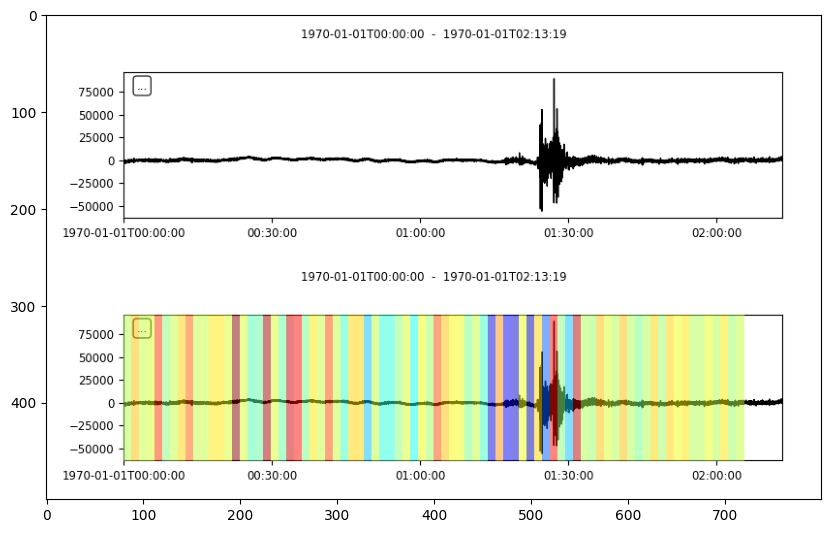

saved 1 files
1 : dataset8k_v4/class7/original/201901_21_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 26ms/step


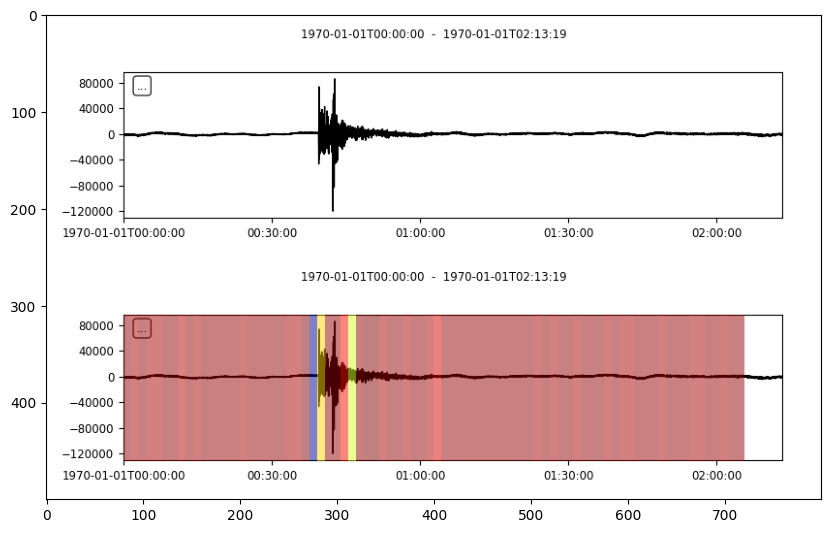

saved 2 files
2 : dataset8k_v4/class7/original/201901_9_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 23ms/step


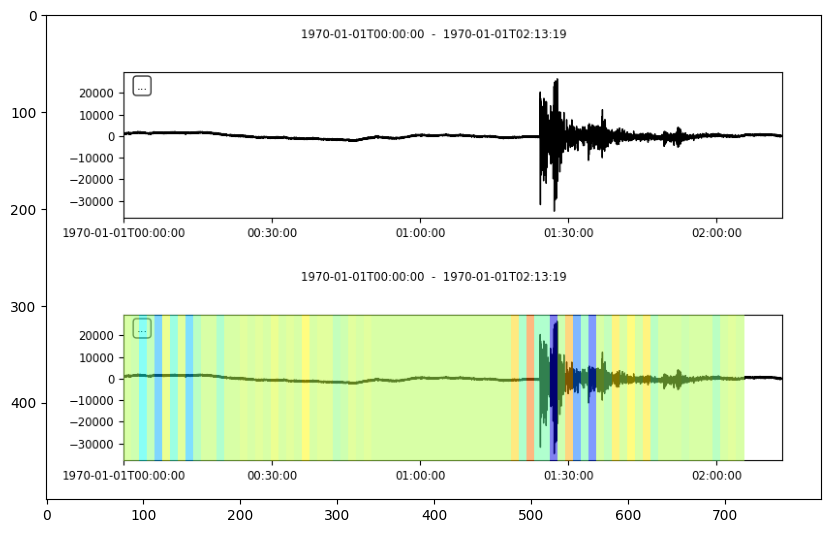

saved 3 files
3 : dataset8k_v4/class7/original/201903_16_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 17ms/step


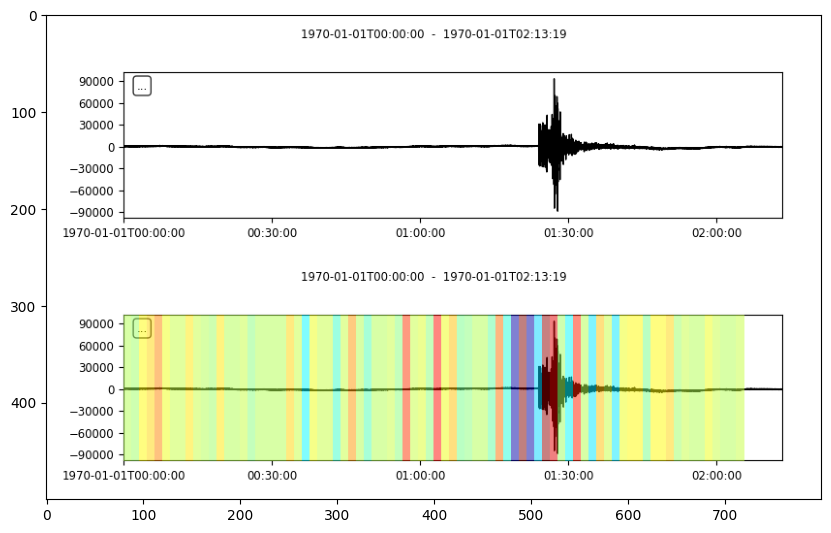

saved 4 files
4 : dataset8k_v4/class7/original/201903_8_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


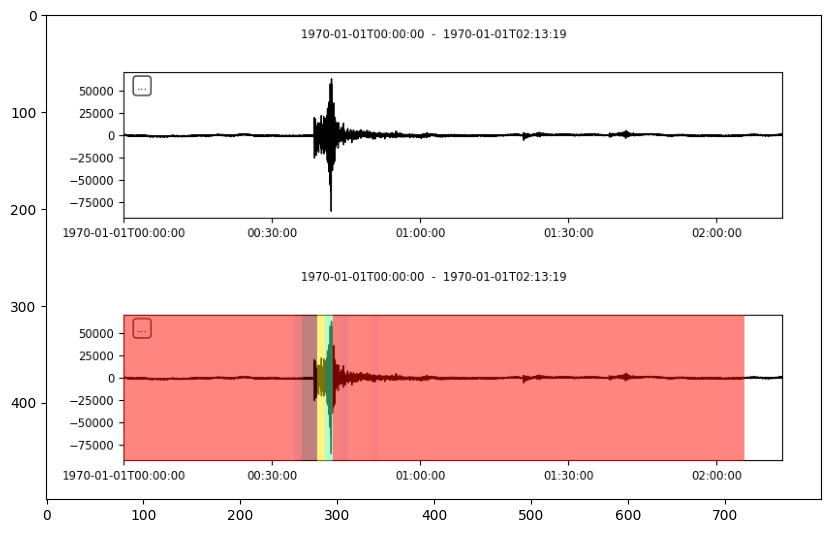

5 : dataset8k_v4/class7/original/201903_9_1__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


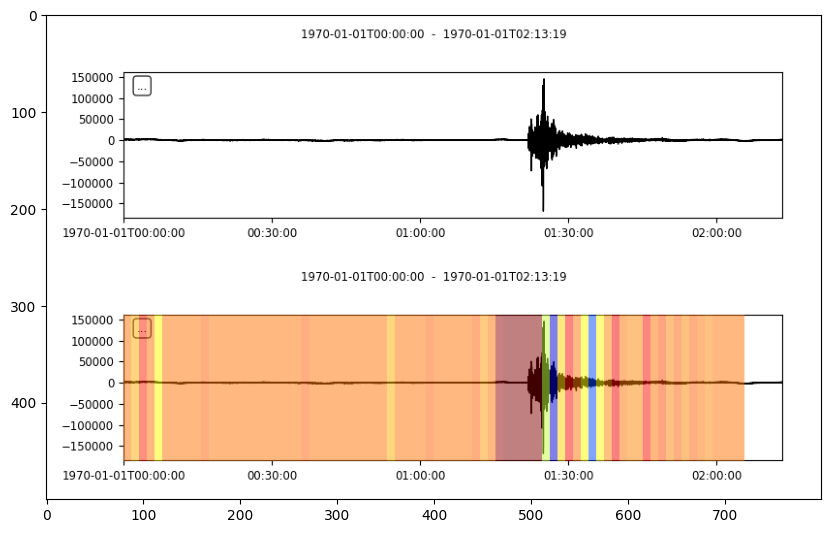

saved 5 files
6 : dataset8k_v4/class7/original/201904_0_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


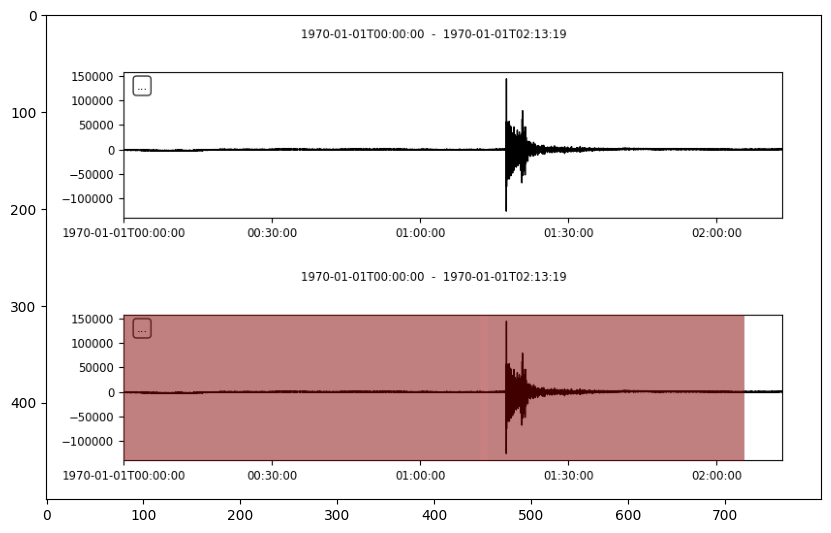

7 : dataset8k_v4/class7/original/201904_9_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


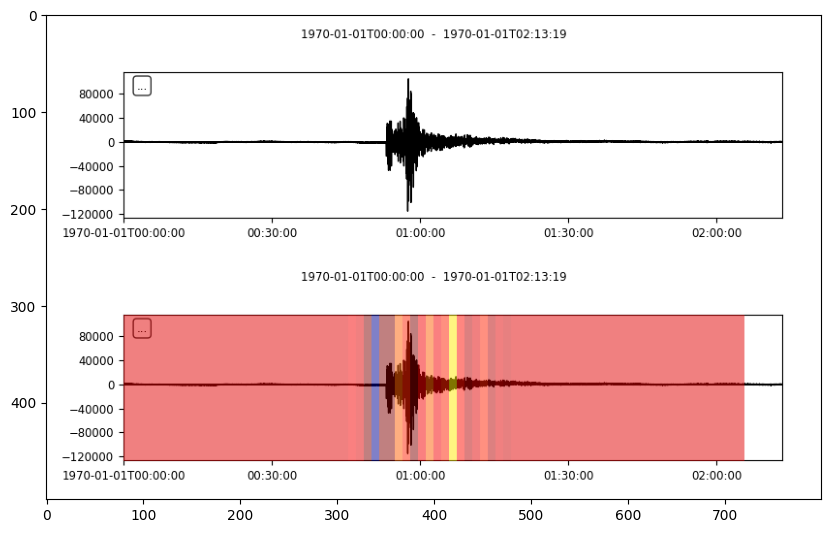

8 : dataset8k_v4/class7/original/201904_9_25__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


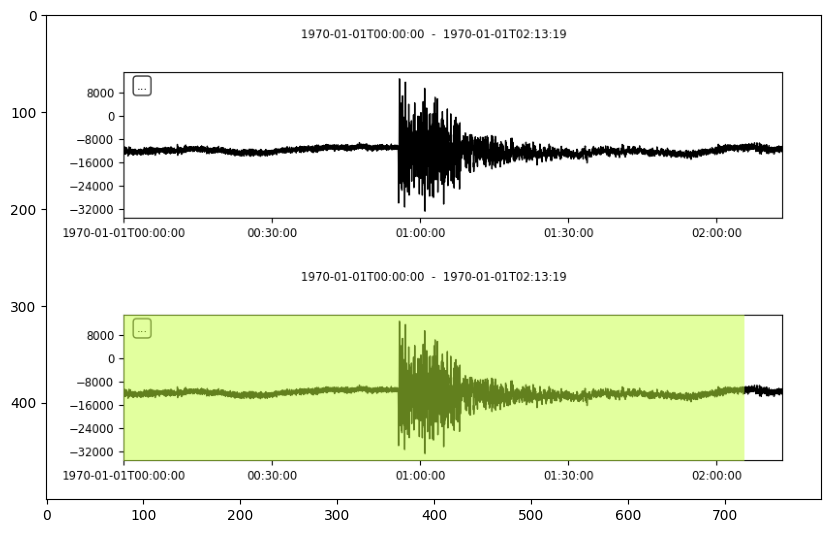

9 : dataset8k_v4/class7/original/201905_0_1__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


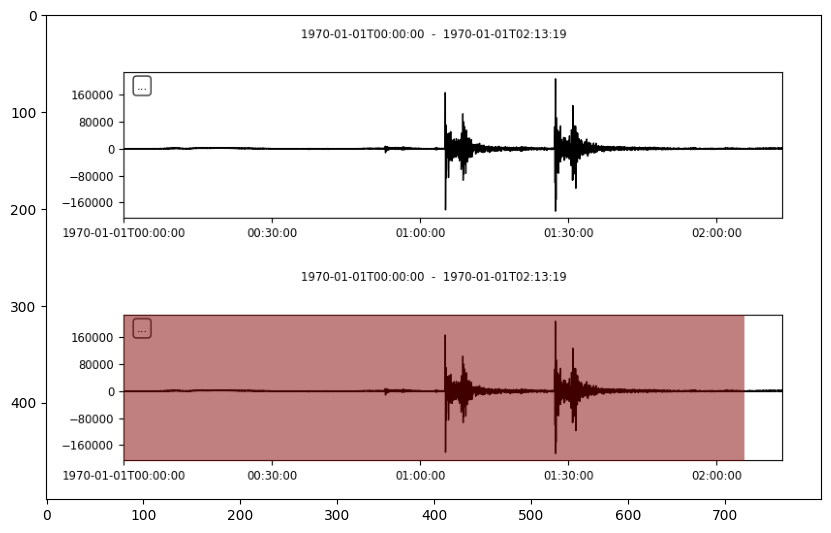

10 : dataset8k_v4/class7/original/201905_8_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


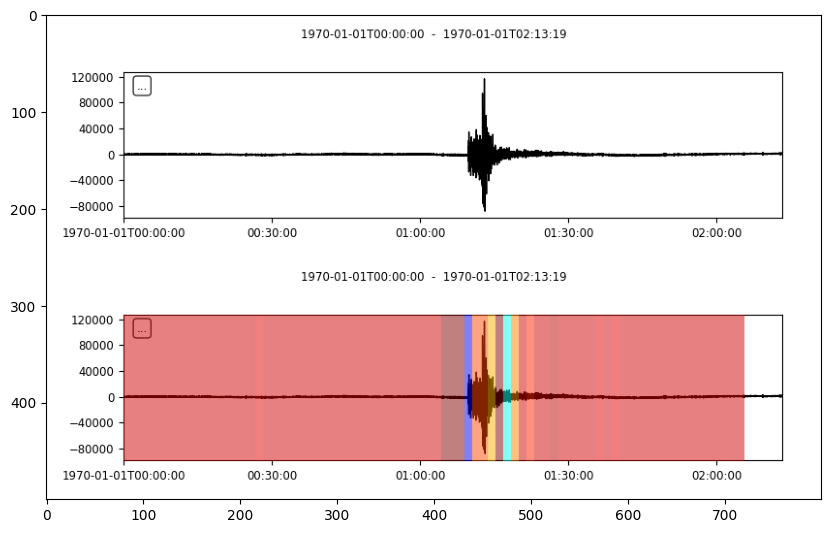

saved 6 files
11 : dataset8k_v4/class7/original/201906_7_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 24ms/step


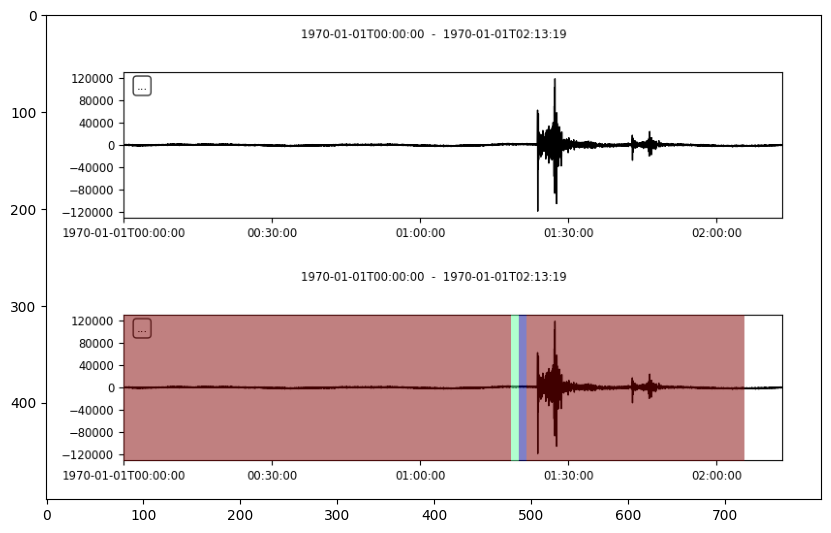

12 : dataset8k_v4/class7/original/201907_16_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


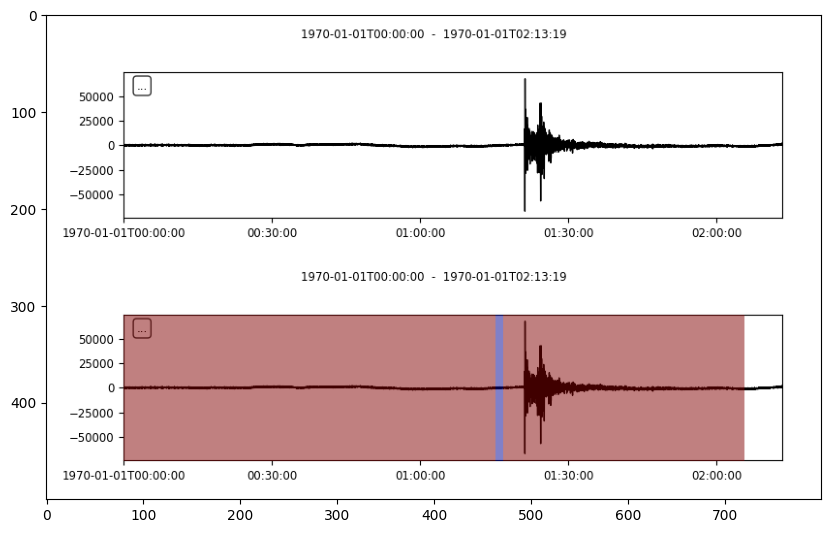

13 : dataset8k_v4/class7/original/201907_19_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


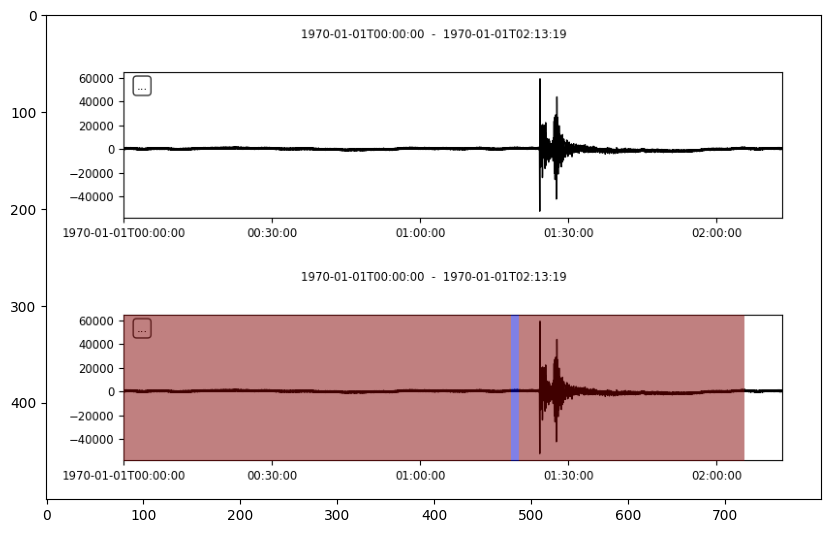

14 : dataset8k_v4/class7/original/201907_21_47__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


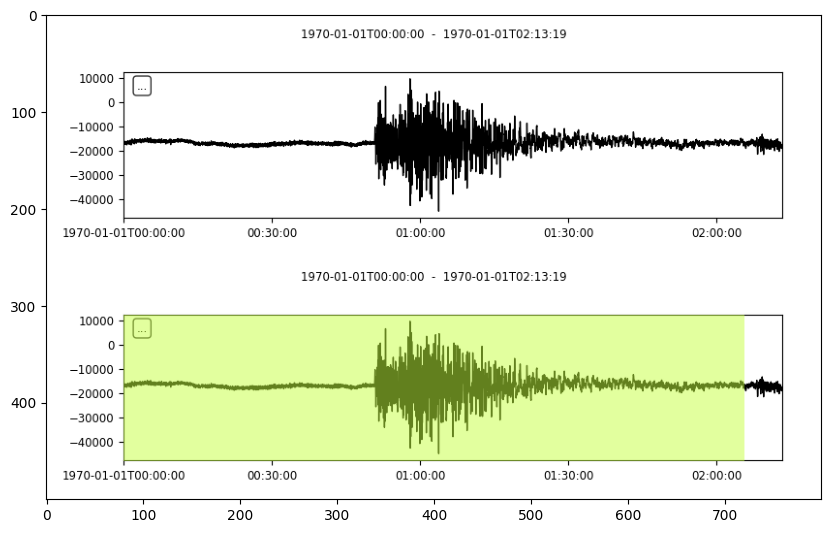

15 : dataset8k_v4/class7/original/201907_6_24__KO.SIMA..BHZ.D.2019.195.170358.SAC_original.sac
1/1 [==============================] - 0s 19ms/step


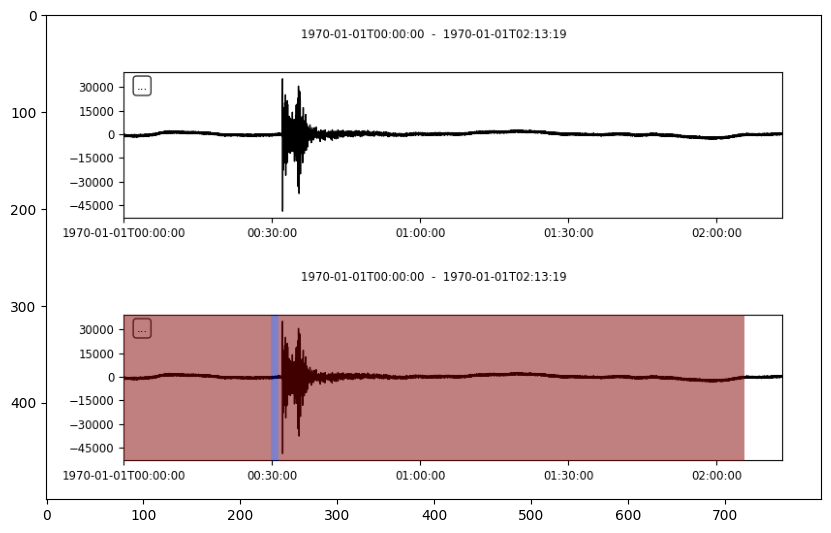

16 : dataset8k_v4/class7/original/201908_0_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


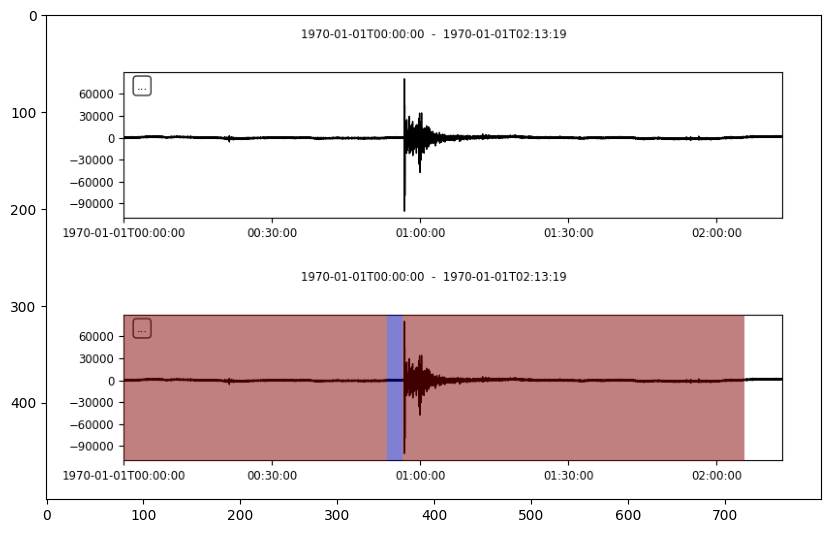

17 : dataset8k_v4/class7/original/201909_0_65__TVSB.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


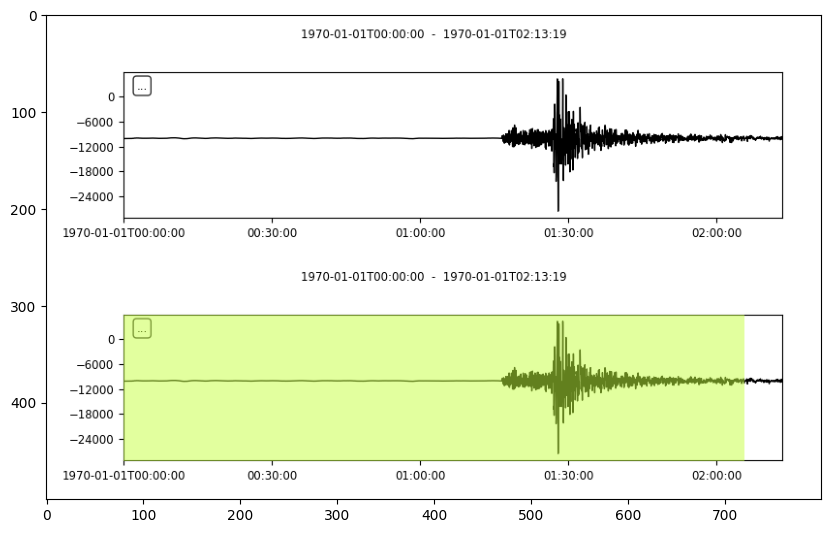

18 : dataset8k_v4/class7/original/201909_13_20__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


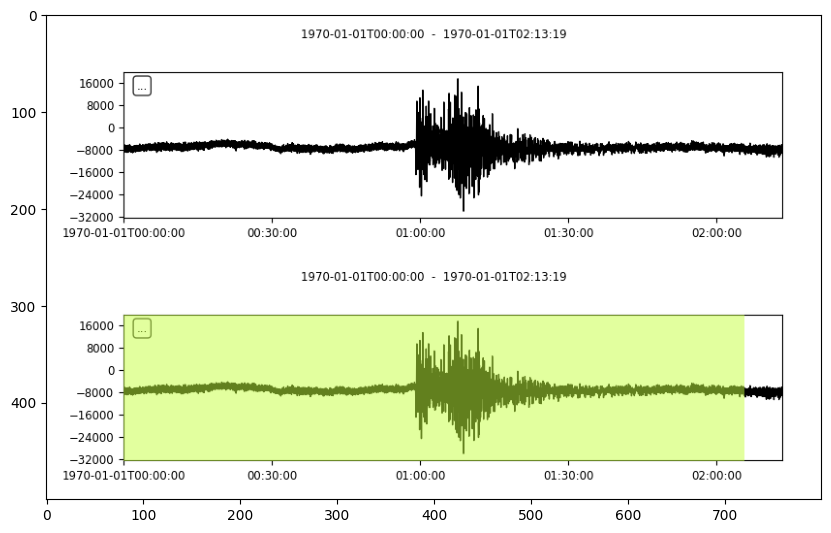

19 : dataset8k_v4/class7/original/201910_18_4__YAYO.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


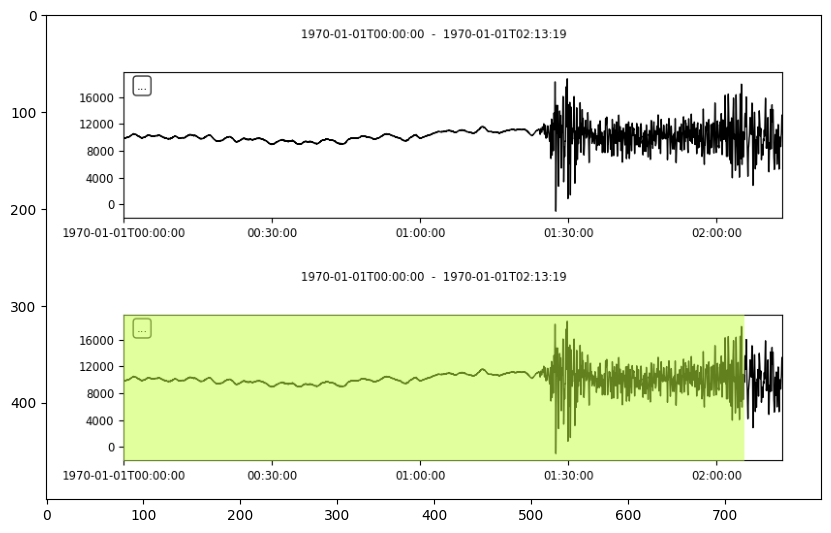

20 : dataset8k_v4/class7/original/201910_19_105__MDNY.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


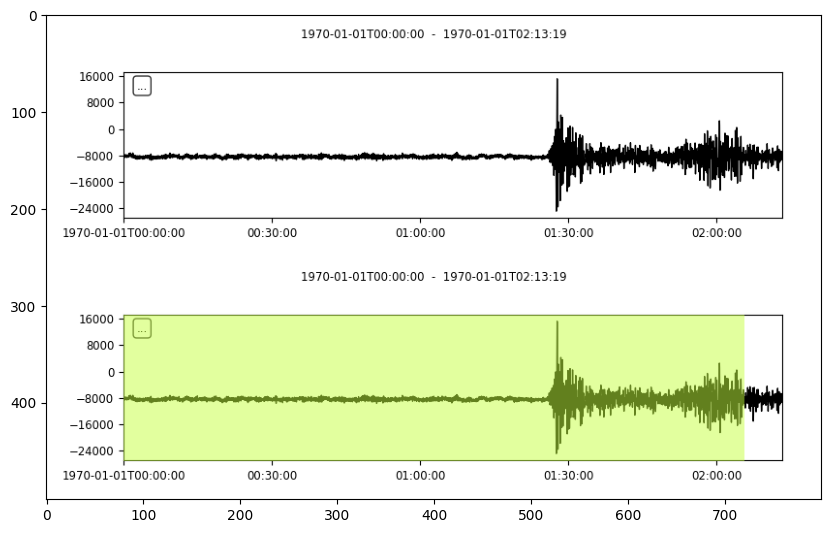

21 : dataset8k_v4/class7/original/201910_4_67__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


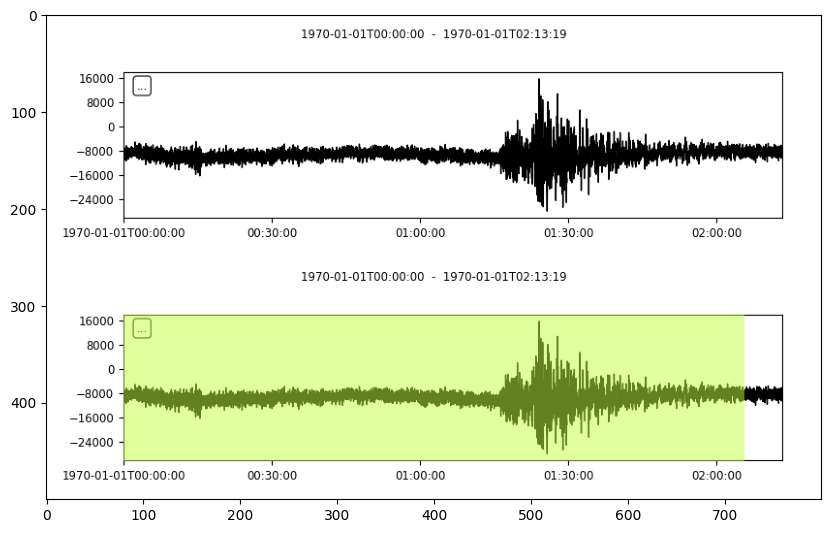

22 : dataset8k_v4/class7/original/201911_16_4__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


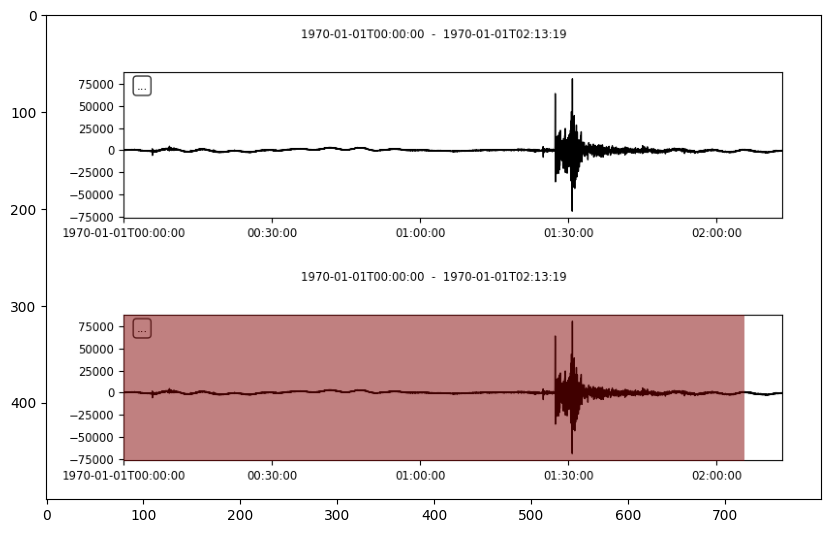

23 : dataset8k_v4/class7/original/201911_22_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


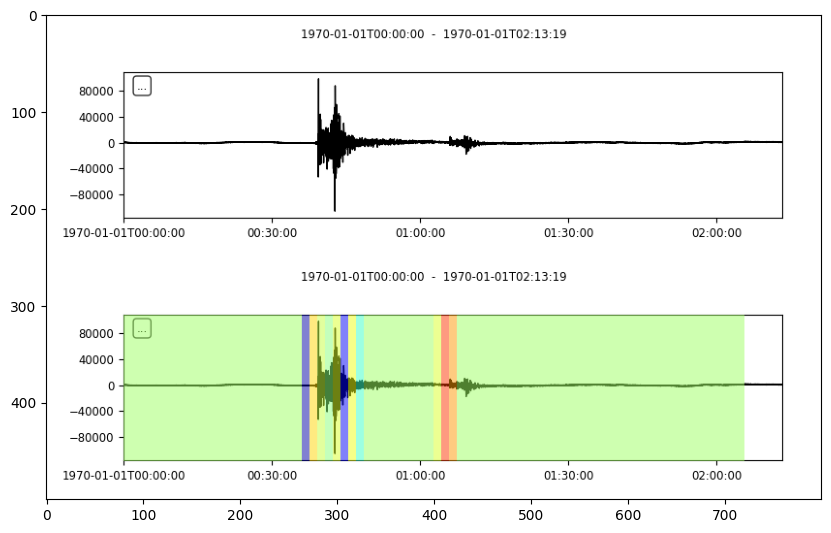

saved 7 files
24 : dataset8k_v4/class7/original/201911_3_40__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


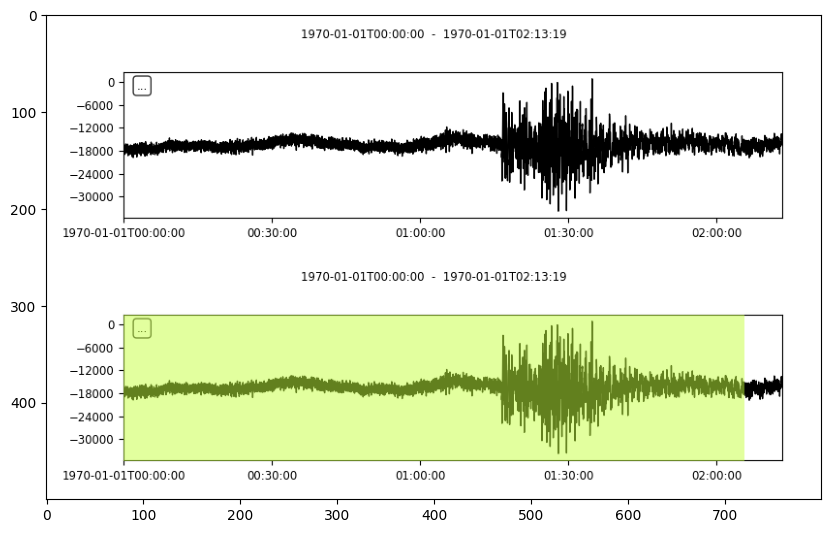

25 : dataset8k_v4/class7/original/201911_5_60__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


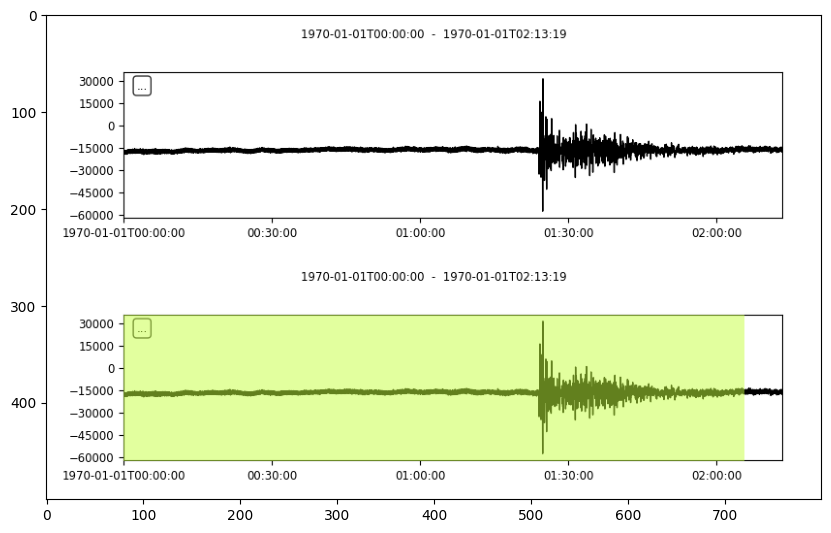

26 : dataset8k_v4/class7/original/201912_11_105__TVSB.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


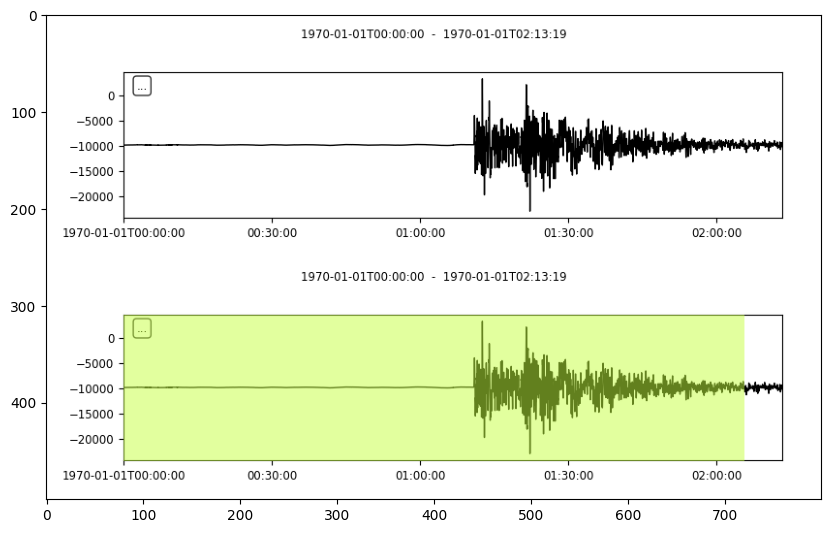

27 : dataset8k_v4/class7/original/201912_11_5__YAYO.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


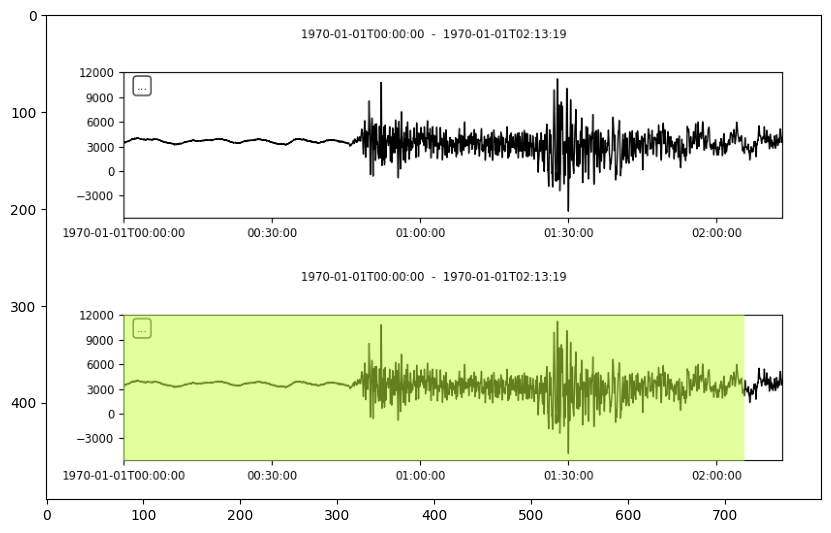

28 : dataset8k_v4/class7/original/201912_15_4__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


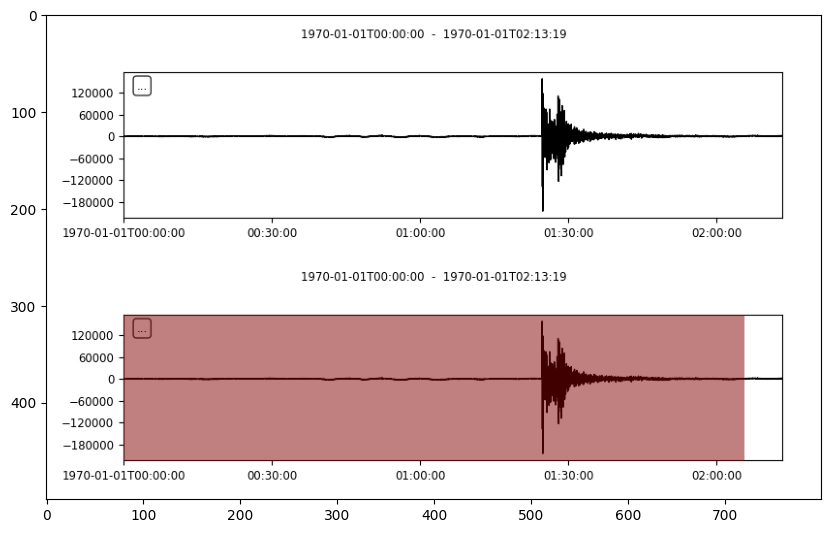

29 : dataset8k_v4/class7/original/201912_1_4__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


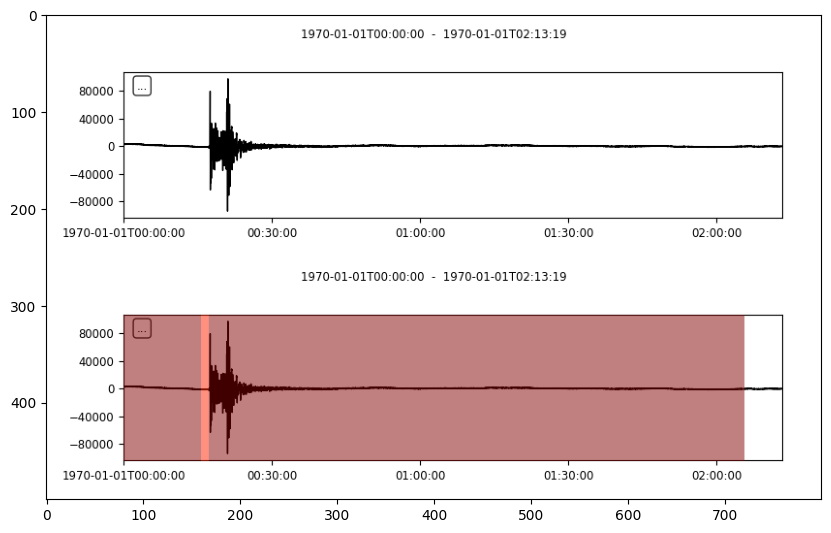

30 : dataset8k_v4/class7/original/201912_3_0__SIMA.BHZ.KO_original.sac


2023-06-21 19:52:19.508383: I tensorflow/core/common_runtime/executor.cc:1197] [/job:localhost/replica:0/task:0/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: Matrix size-incompatible: In[0]: [1,4632], In[1]: [3984,8]
	 [[{{node sequential/dense/Relu}}]]


InvalidArgumentError: Graph execution error:

Detected at node 'sequential/dense/Relu' defined at (most recent call last):
    File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/home/mbulucay/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1043, in launch_instance
      app.start()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 725, in start
      self.io_loop.start()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 215, in start
      self.asyncio_loop.run_forever()
    File "/usr/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
      self._run_once

In [6]:

cs = 0 
for i, trace_file in enumerate(original_trace_file_list):
    path = os.path.join(dataset, original_class_folder, trace_file) 
    print(f"{i} : {path}")
    trace, pred, p_l = colorize(path, divide_number = 80)
    x = input("Press Enter to continue...")
    if x == 'q':
        break
    elif x == 's':
        # copy the file to another folder
        trace.write("./dataset/" + trace_file, format="SAC")
        cs = cs + 1
        print(f"saved {cs} files")




0 : dataset8k_v4/class7/original/202001_14_2__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


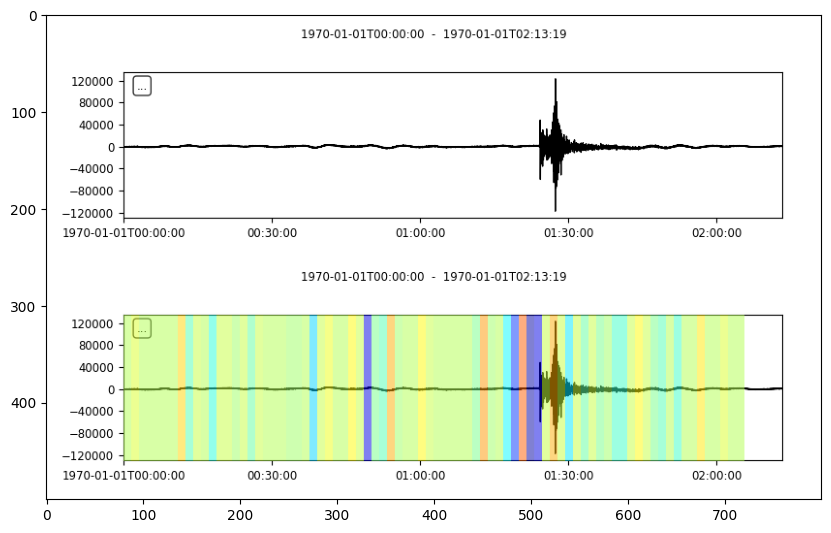

saved 1 files
1 : dataset8k_v4/class7/original/202002_22_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


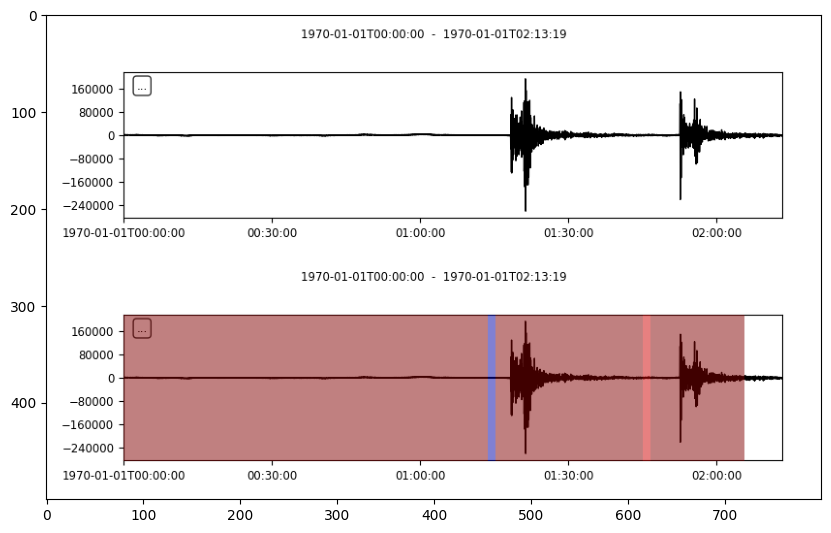

saved 2 files
2 : dataset8k_v4/class7/original/202002_7_31__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


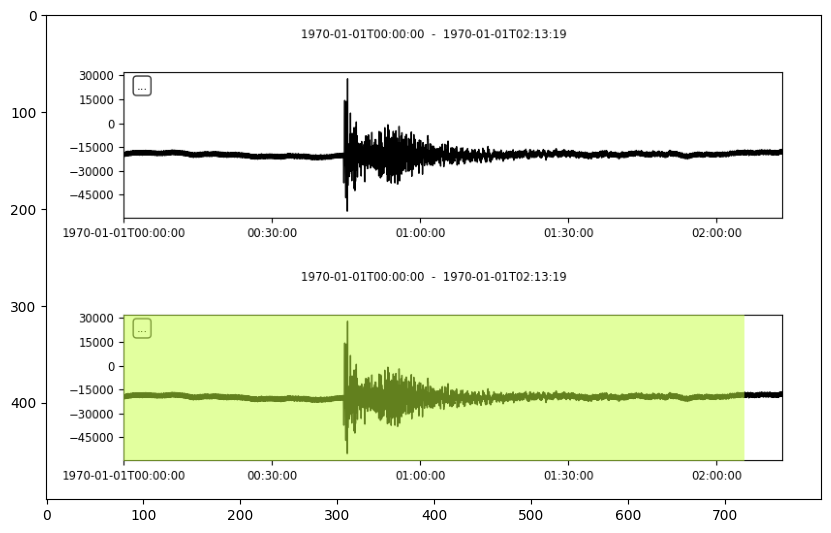

3 : dataset8k_v4/class7/original/202003_0_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


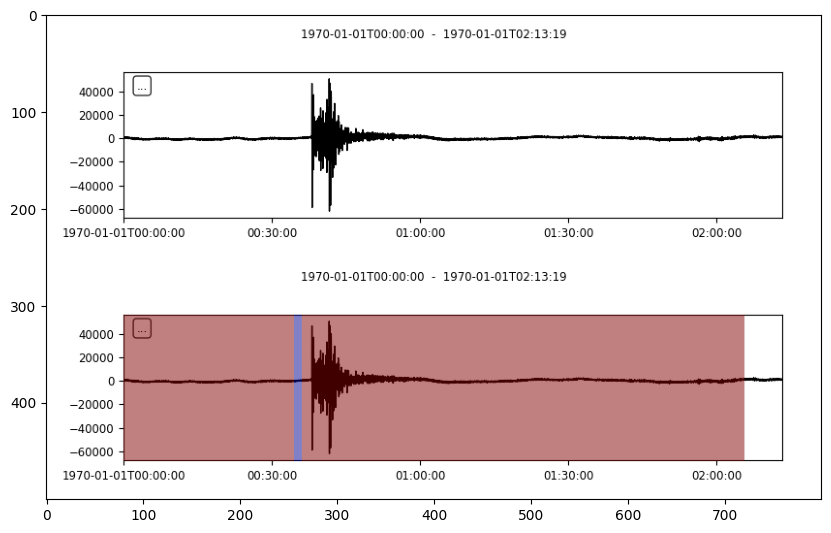

4 : dataset8k_v4/class7/original/202003_18_2__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


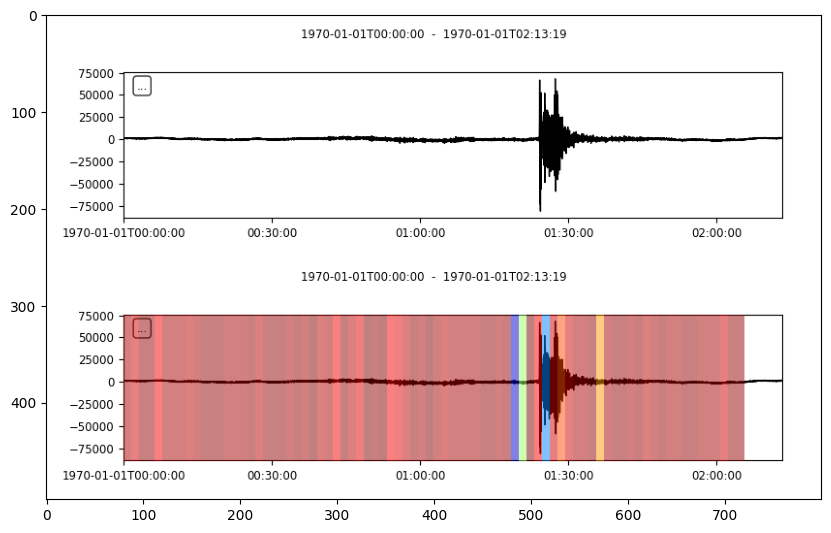

saved 3 files
5 : dataset8k_v4/class7/original/202004_13_74__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


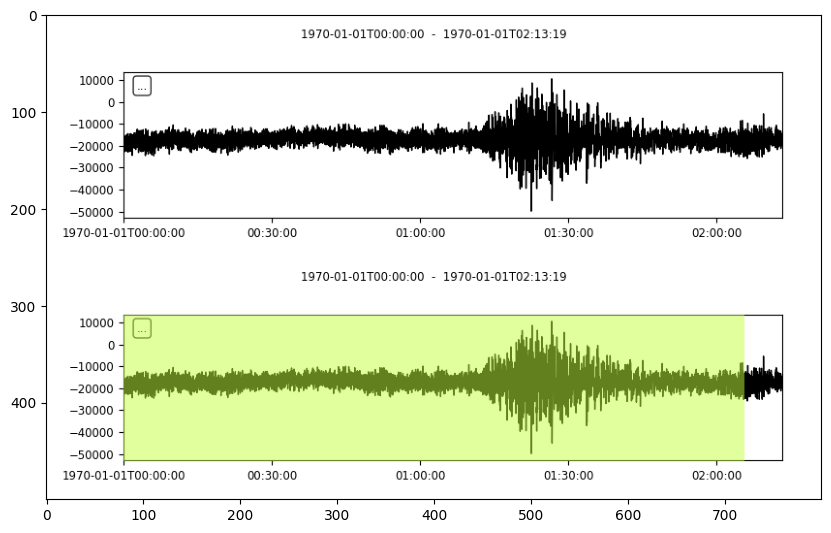

6 : dataset8k_v4/class7/original/202004_2_2__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


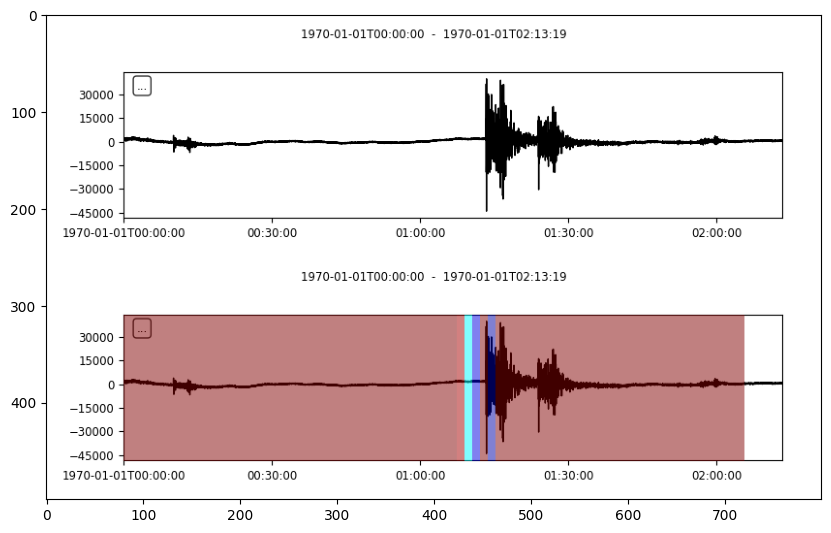

7 : dataset8k_v4/class7/original/202004_6_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


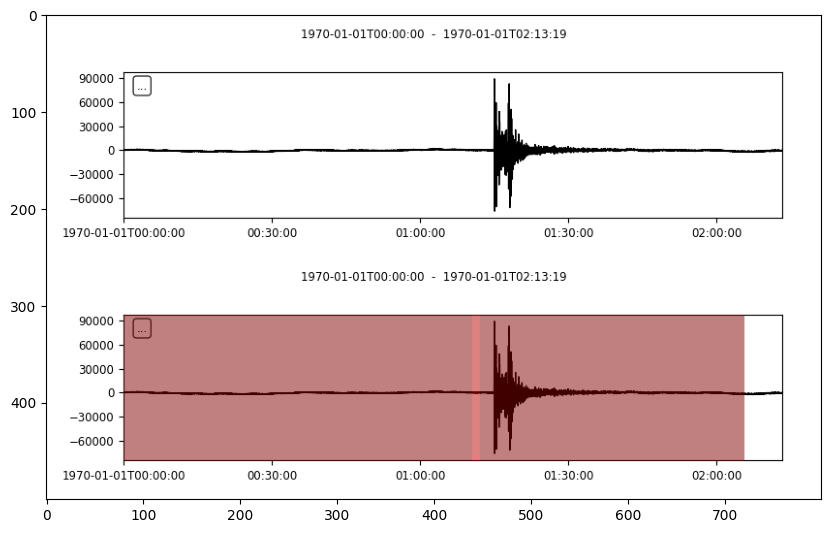

8 : dataset8k_v4/class7/original/202005_1_0__BALB.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


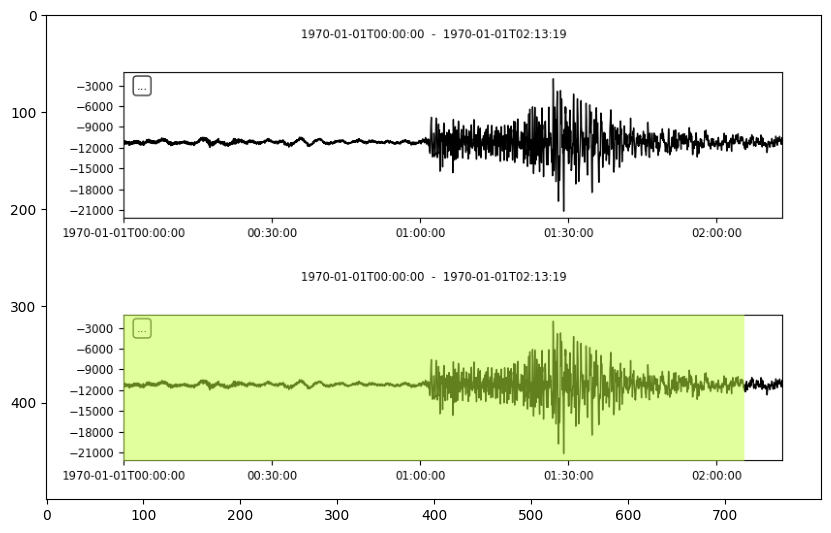

9 : dataset8k_v4/class7/original/202005_1_38__KCTX.BHZ.KO_original.sac
1/1 [==============================] - 0s 23ms/step


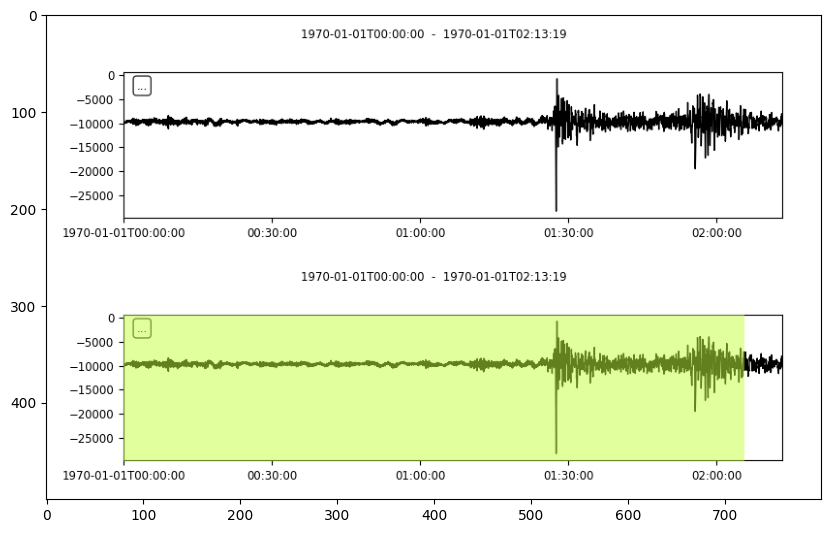

10 : dataset8k_v4/class7/original/202005_1_55__TVSB.BHZ.KO_original.sac
1/1 [==============================] - 0s 17ms/step


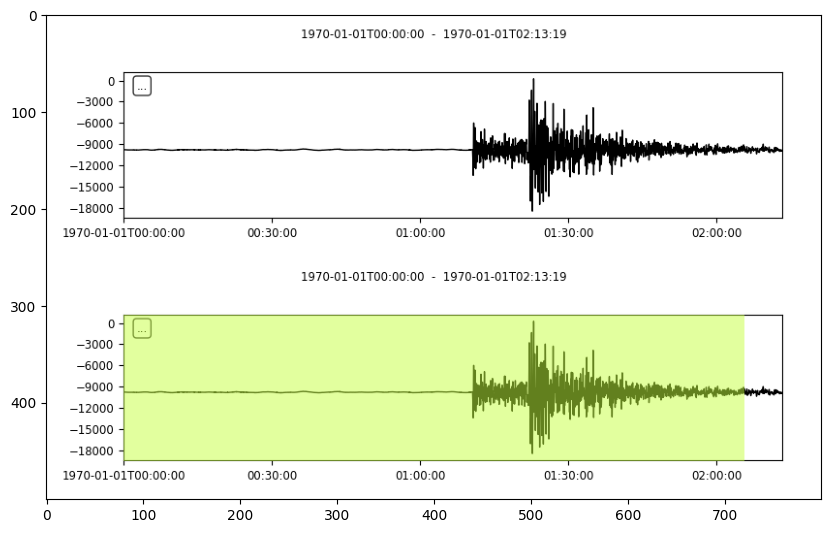

11 : dataset8k_v4/class7/original/202005_1_70__MDNY.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


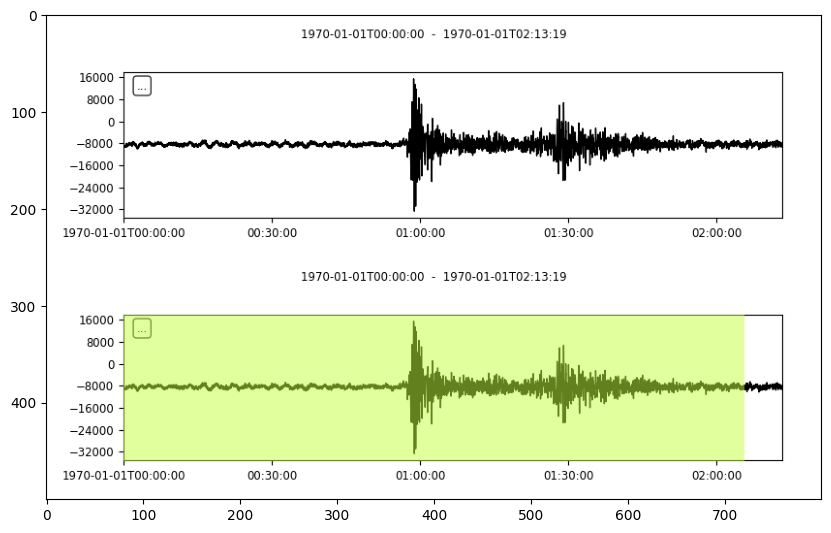

12 : dataset8k_v4/class7/original/202005_20_0__BALB.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


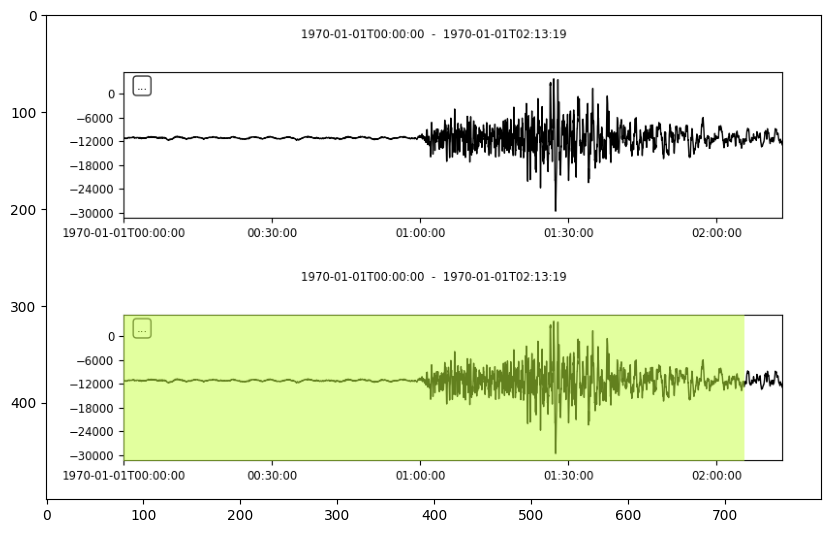

13 : dataset8k_v4/class7/original/202005_20_36__KCTX.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


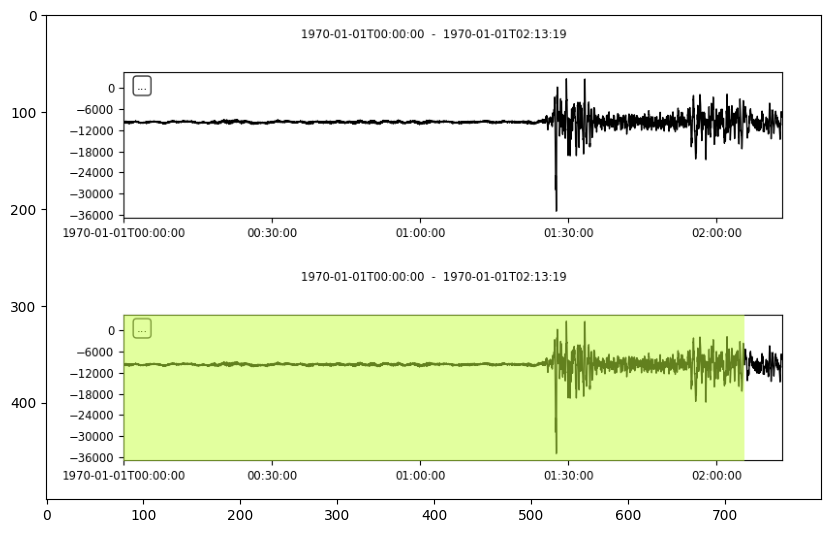

14 : dataset8k_v4/class7/original/202005_7_3__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 21ms/step


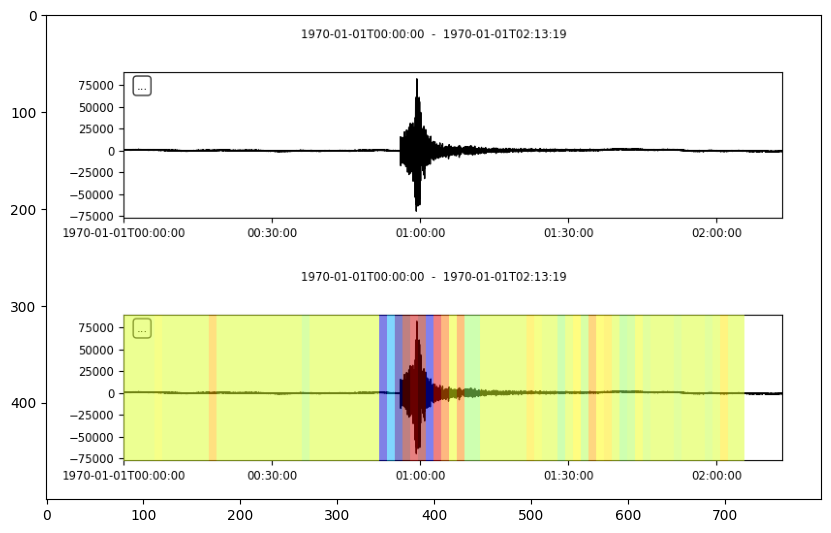

saved 4 files
15 : dataset8k_v4/class7/original/202005_9_15__KULA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


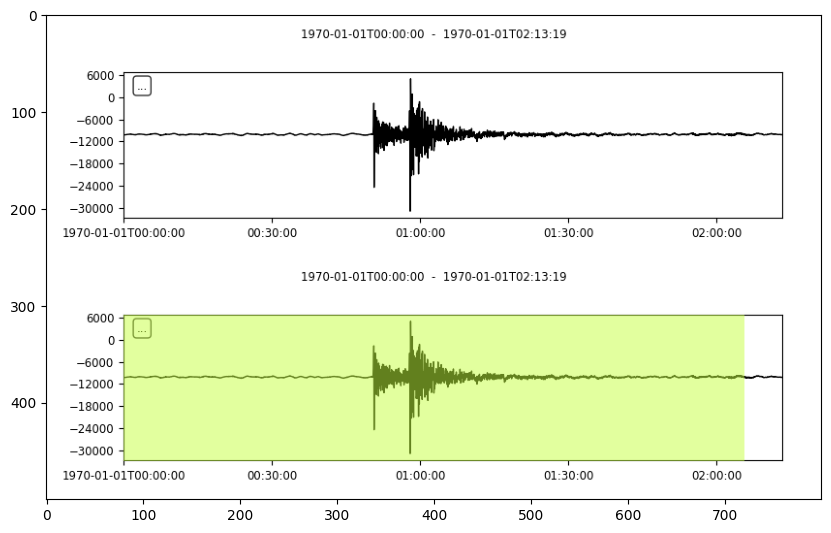

16 : dataset8k_v4/class7/original/202005_9_40__KCTX.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


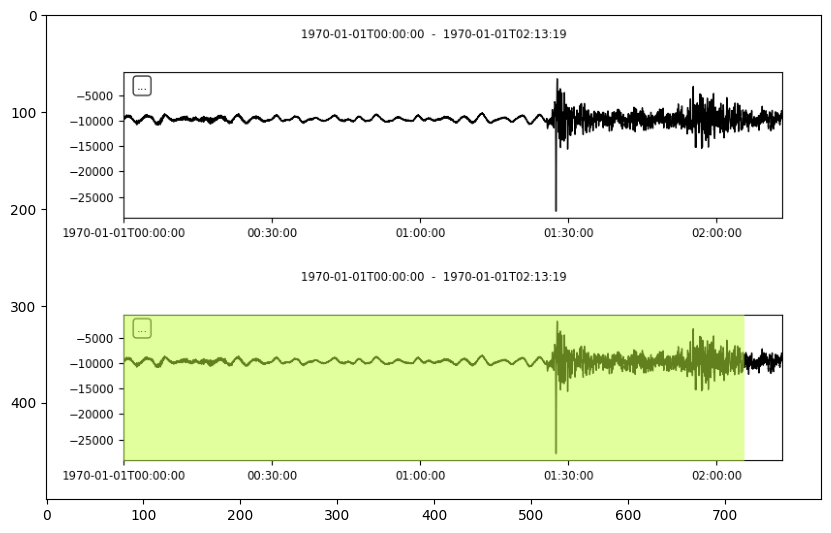

17 : dataset8k_v4/class7/original/202005_9_59__TVSB.BHZ.KO_original.sac
1/1 [==============================] - 0s 23ms/step


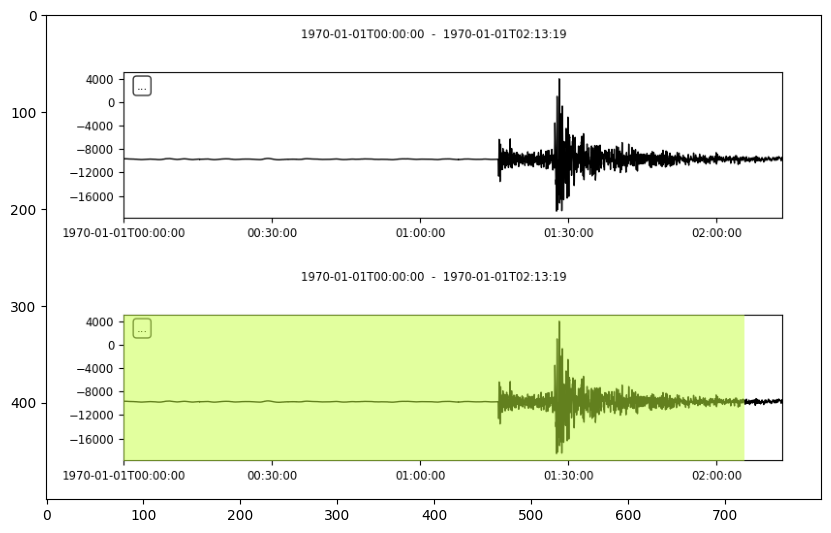

18 : dataset8k_v4/class7/original/202006_11_2__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


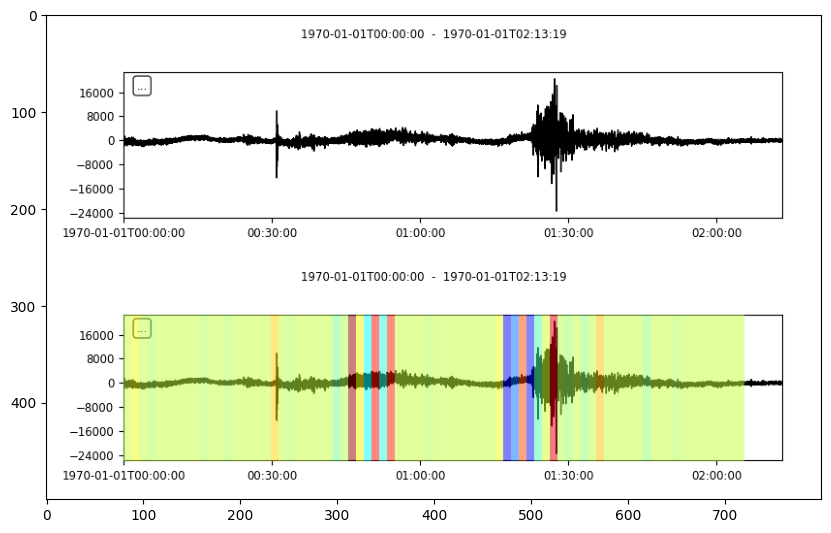

saved 5 files
19 : dataset8k_v4/class7/original/202007_14_33__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


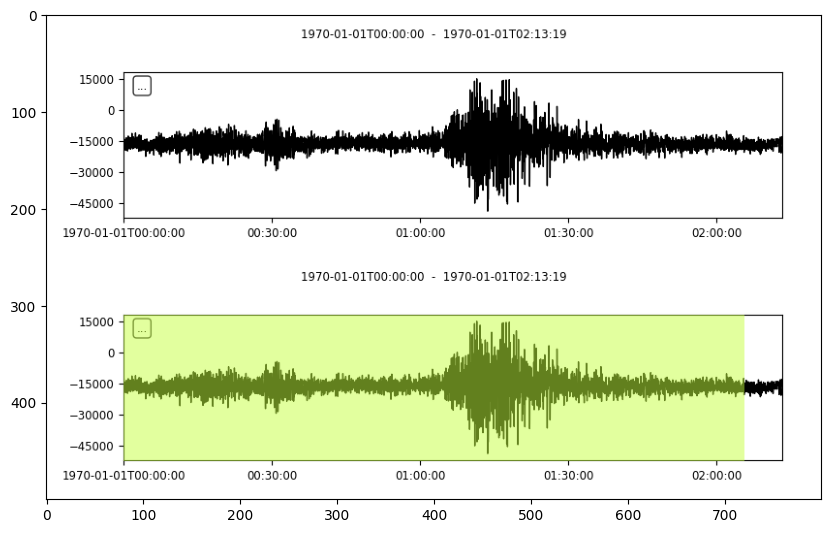

20 : dataset8k_v4/class7/original/202007_4_84__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


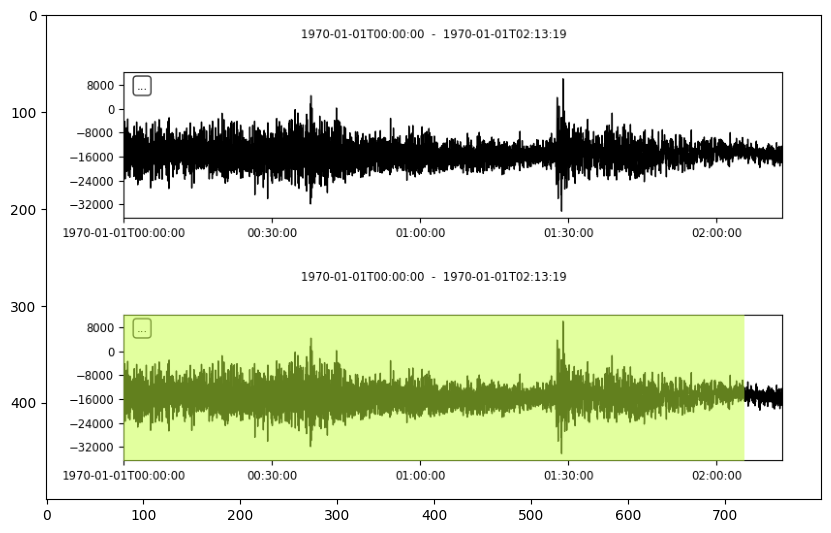

21 : dataset8k_v4/class7/original/202008_10_100__GULT.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


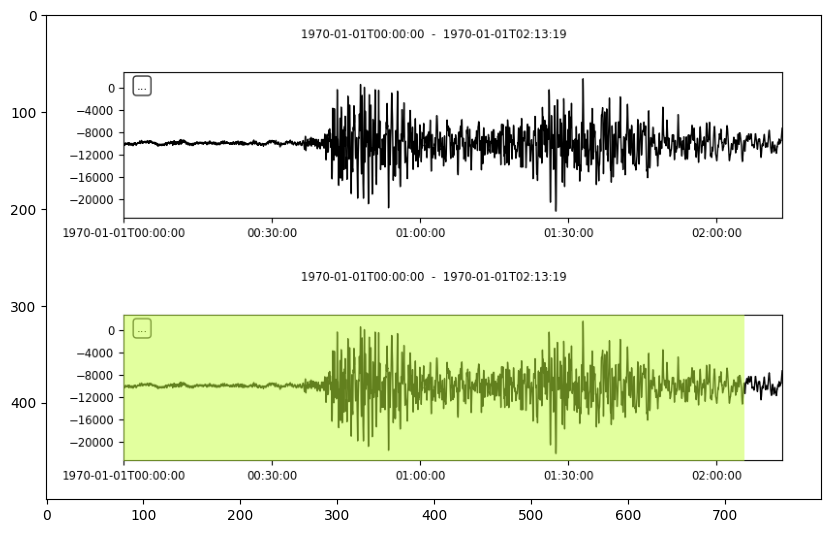

22 : dataset8k_v4/class7/original/202008_10_18__CAVI.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


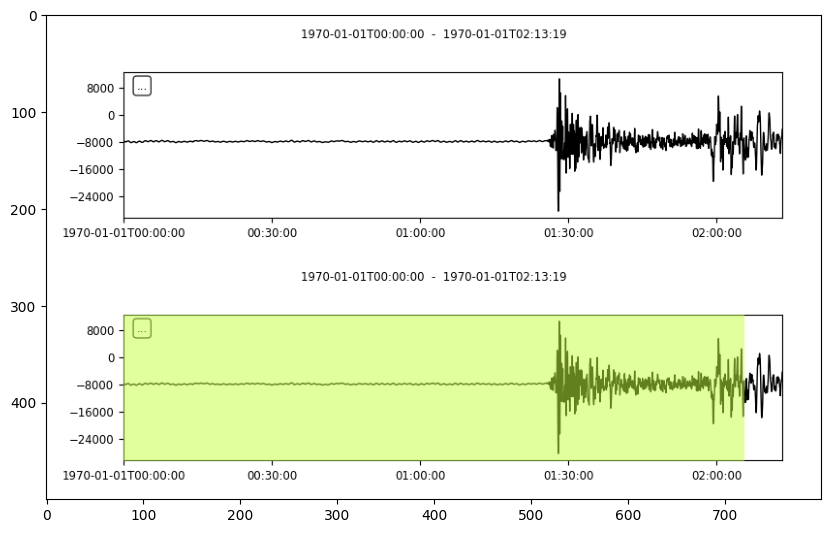

23 : dataset8k_v4/class7/original/202008_10_19__KULA.BHZ.KO_original.sac
1/1 [==============================] - 0s 17ms/step


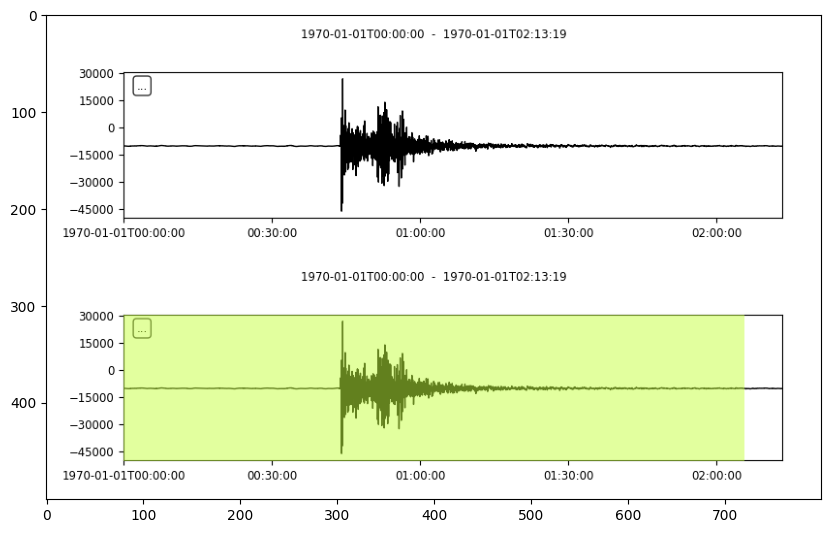

24 : dataset8k_v4/class7/original/202008_10_5__GEML.BHZ.KO_original.sac
1/1 [==============================] - 0s 24ms/step


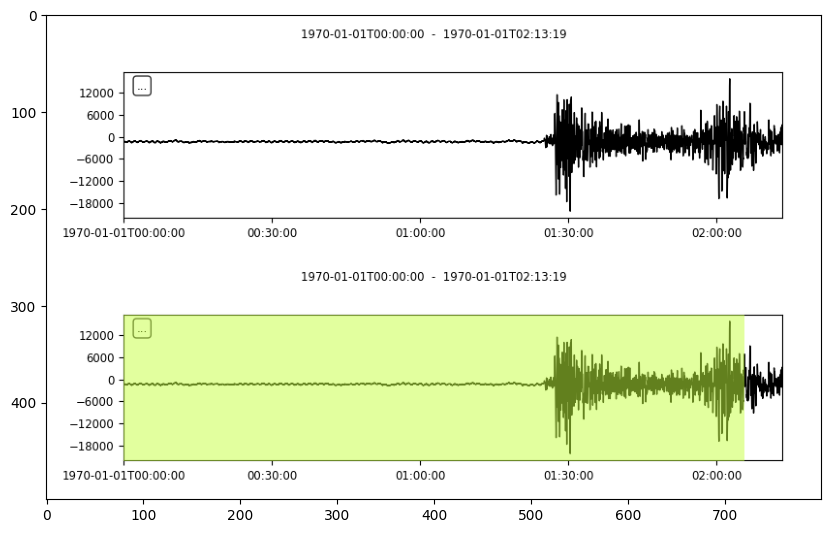

25 : dataset8k_v4/class7/original/202008_10_60__TVSB.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


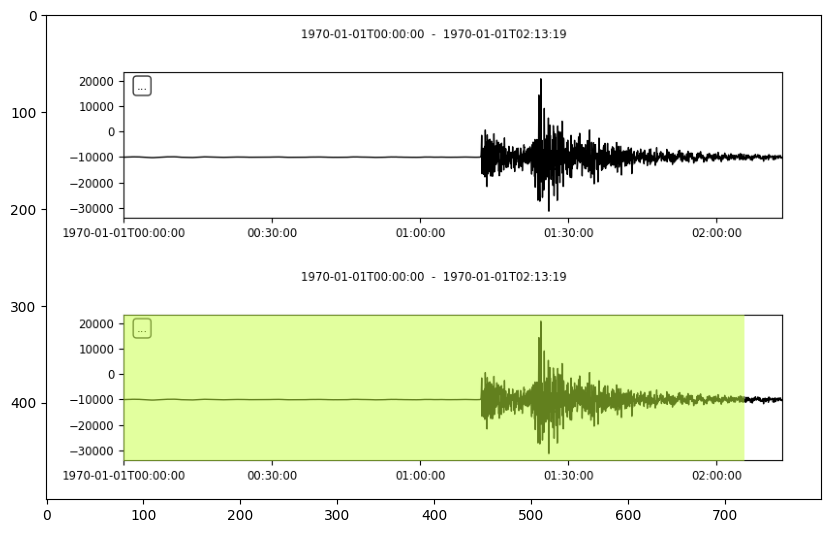

26 : dataset8k_v4/class7/original/202009_19_46__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


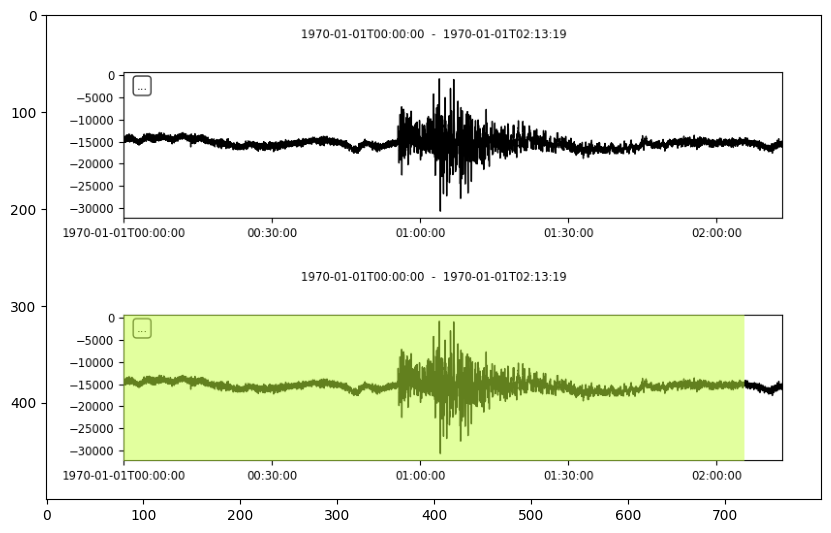

27 : dataset8k_v4/class7/original/202009_20_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


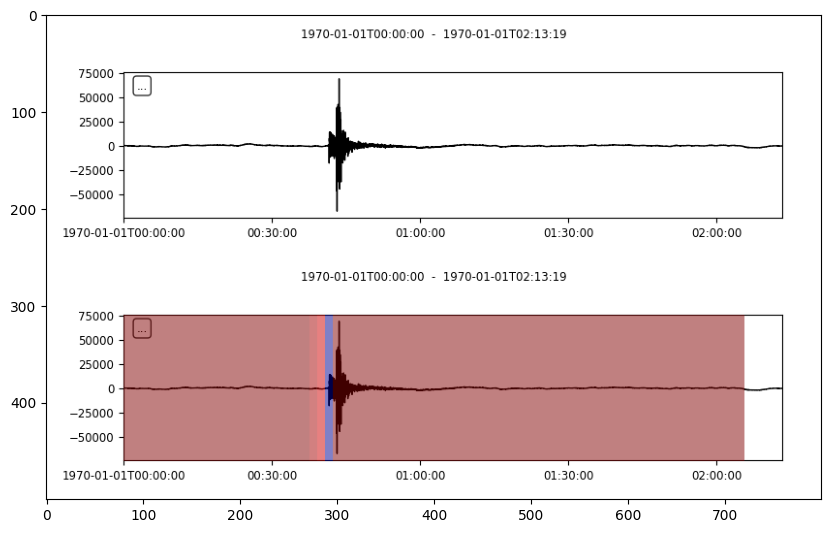

28 : dataset8k_v4/class7/original/202010_10_2__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


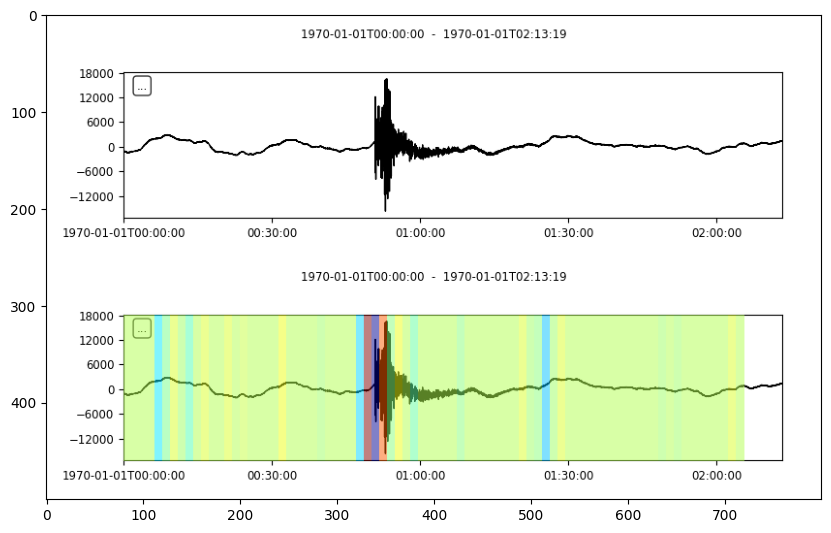

saved 6 files
29 : dataset8k_v4/class7/original/202010_18_3__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 23ms/step


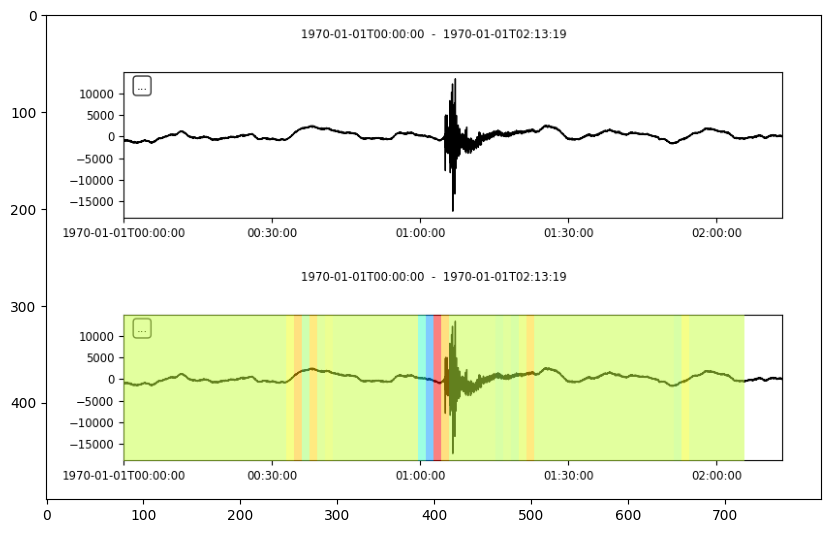

saved 7 files
30 : dataset8k_v4/class7/original/202010_21_30__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 21ms/step


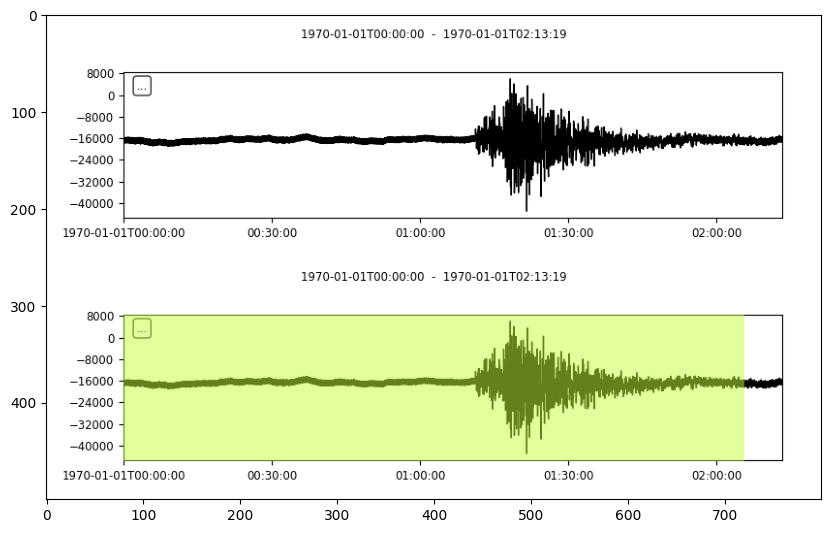

31 : dataset8k_v4/class7/original/202010_33_1__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


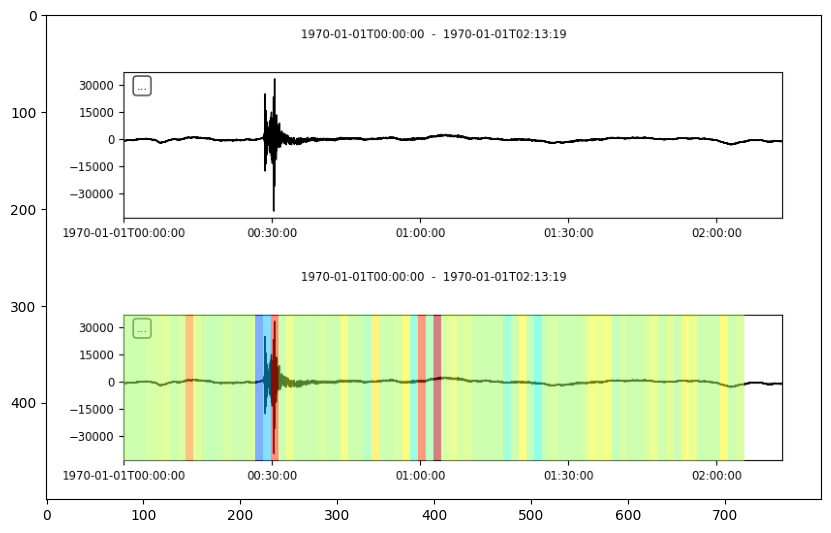

saved 8 files
32 : dataset8k_v4/class7/original/202010_36_65__KCTX.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


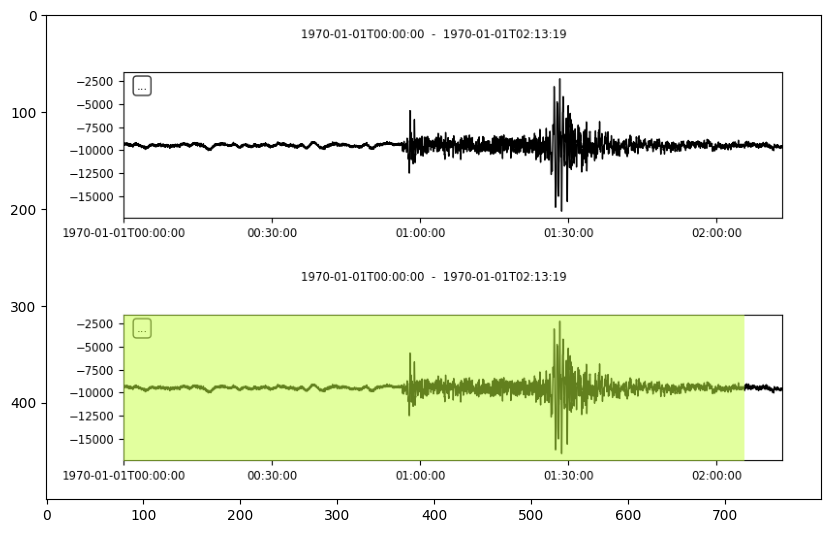

33 : dataset8k_v4/class7/original/202010_5_62__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


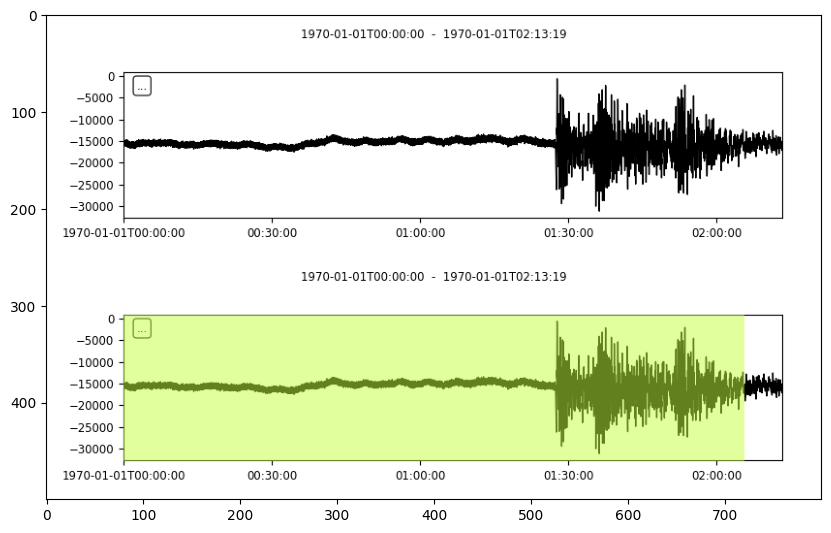

34 : dataset8k_v4/class7/original/202102_15_3__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


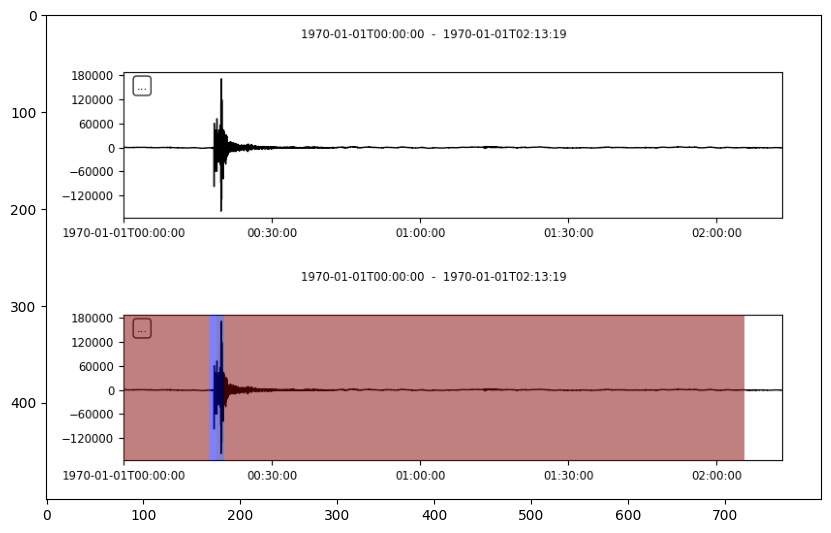

35 : dataset8k_v4/class7/original/202103_15_5__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 21ms/step


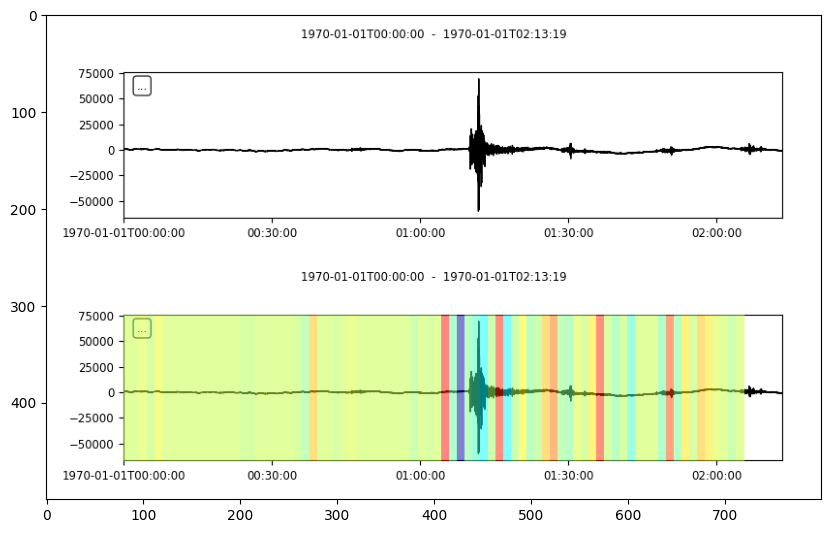

saved 9 files
36 : dataset8k_v4/class7/original/202103_9_0__BALB.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


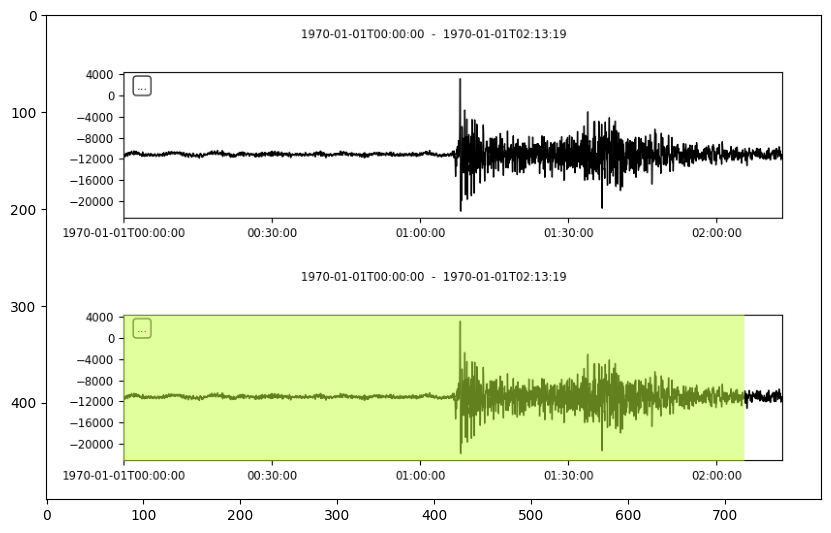

37 : dataset8k_v4/class7/original/202103_9_12__GEML.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


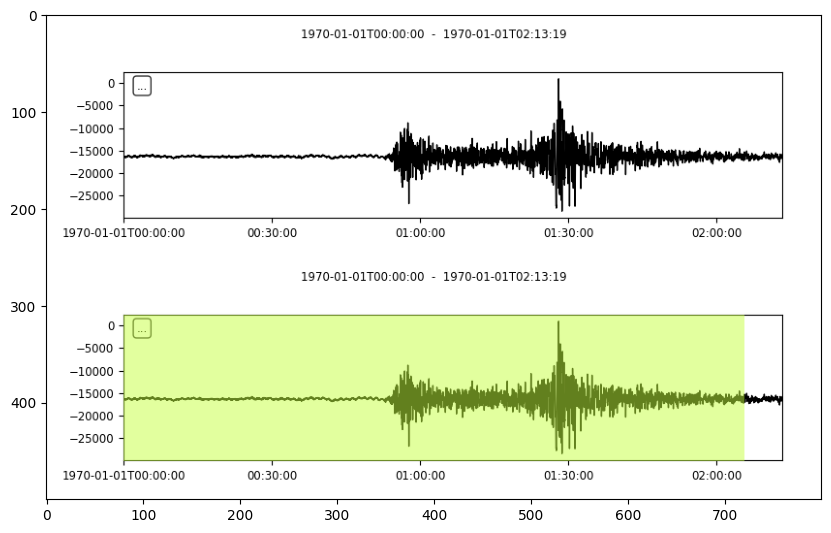

38 : dataset8k_v4/class7/original/202103_9_165__MDNY.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


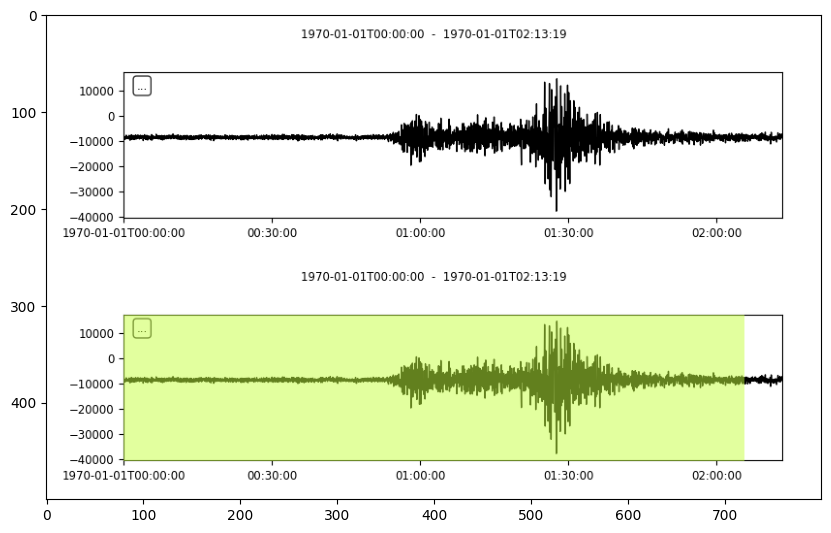

39 : dataset8k_v4/class7/original/202103_9_94__KCTX.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


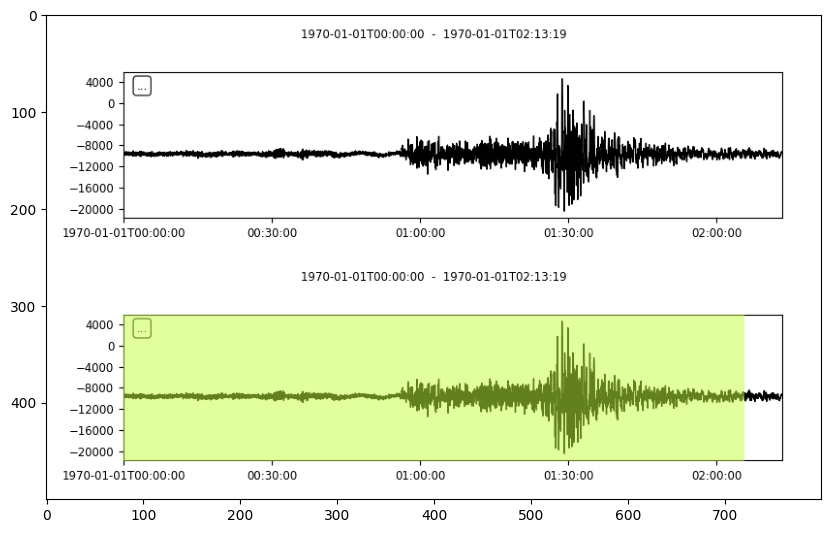

40 : dataset8k_v4/class7/original/202104_0_32__KO.SIMA..BHZ.D.2021.113.134756.SAC_original.sac
1/1 [==============================] - 0s 19ms/step


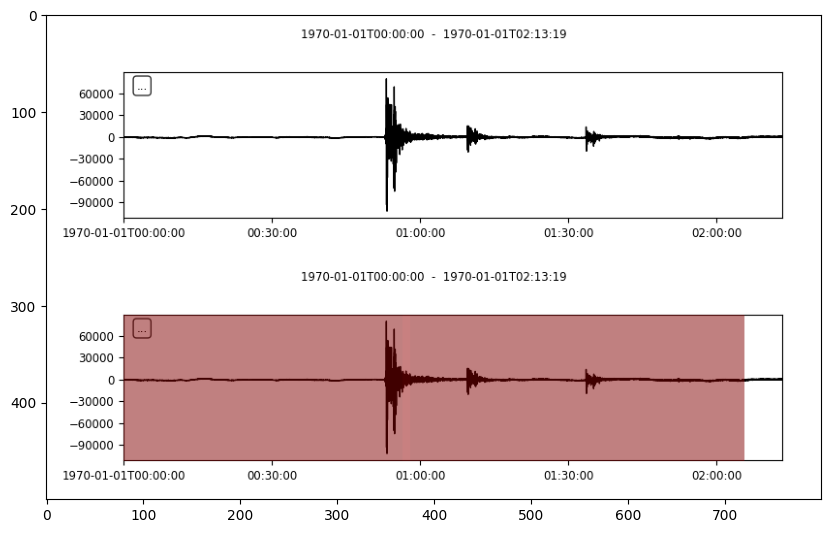

41 : dataset8k_v4/class7/original/202104_15_20__KO.SIMA..BHZ.D.2021.114.103158.SAC_original.sac
1/1 [==============================] - 0s 19ms/step


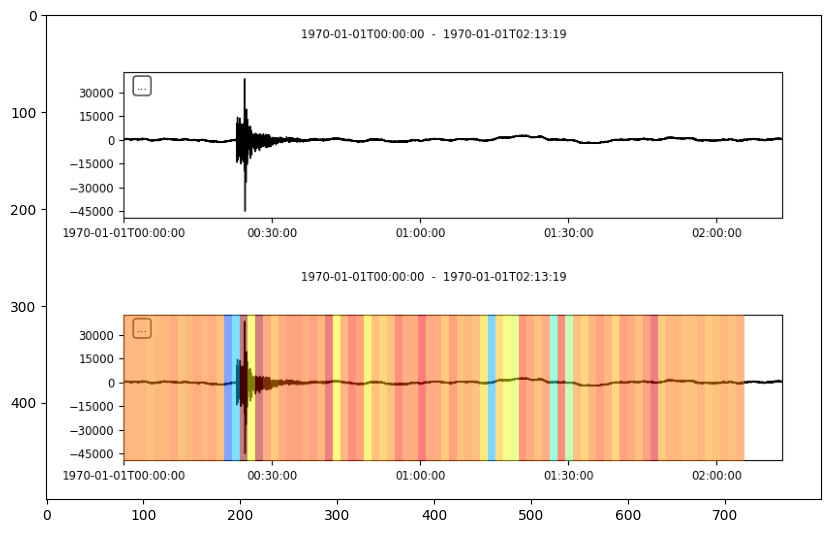

saved 10 files
42 : dataset8k_v4/class7/original/202104_19_5__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


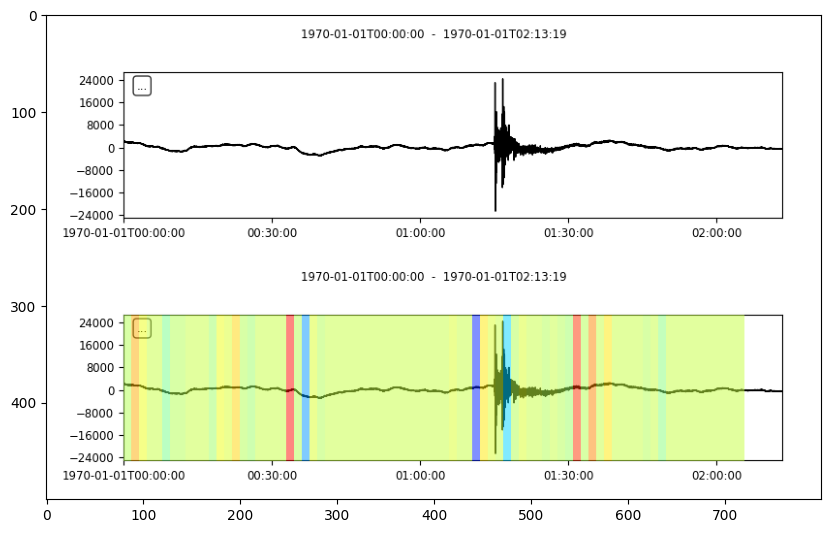

saved 11 files
43 : dataset8k_v4/class7/original/202104_20_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


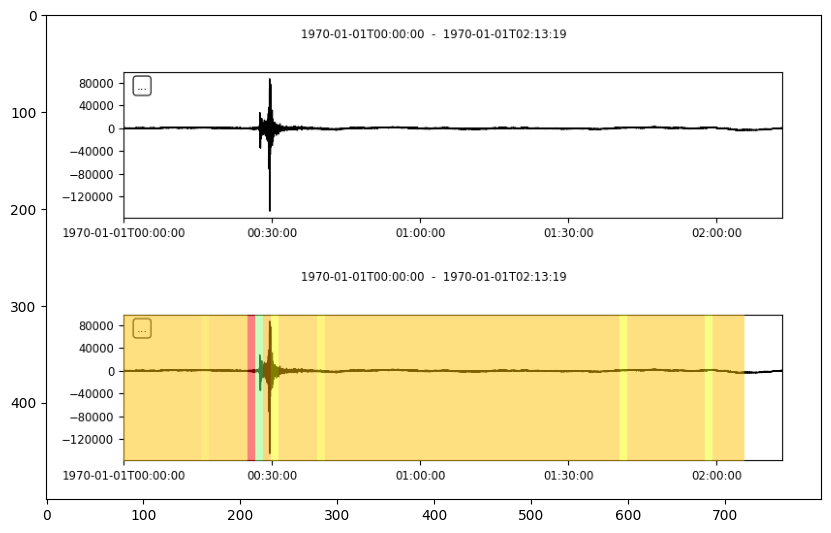

saved 12 files
44 : dataset8k_v4/class7/original/202105_1_53__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


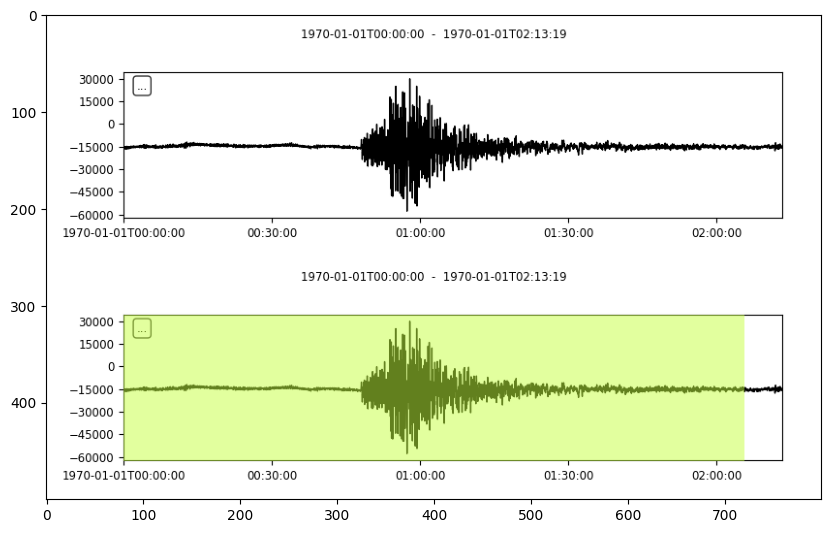

45 : dataset8k_v4/class7/original/202111_15_2__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


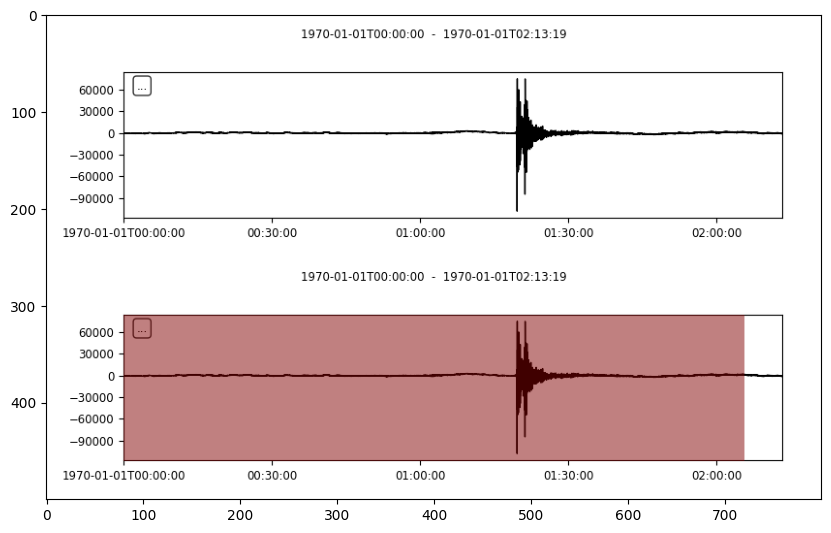

46 : dataset8k_v4/class7/original/202111_9_49__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


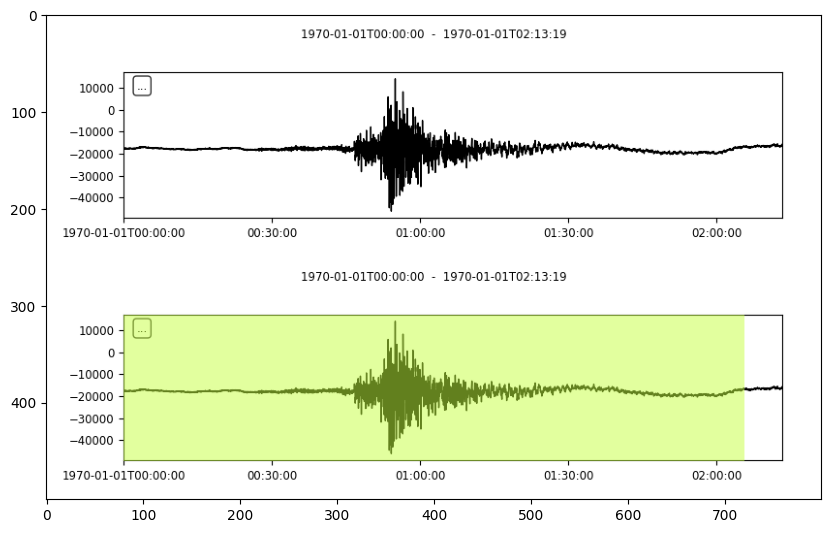

47 : dataset8k_v4/class7/original/202112_12_22__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 18ms/step


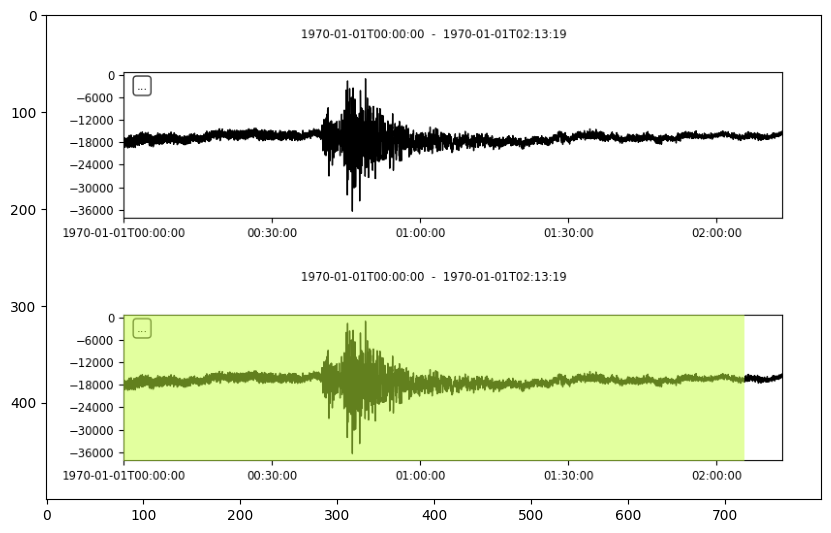

48 : dataset8k_v4/class7/original/202201_8_121__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 21ms/step


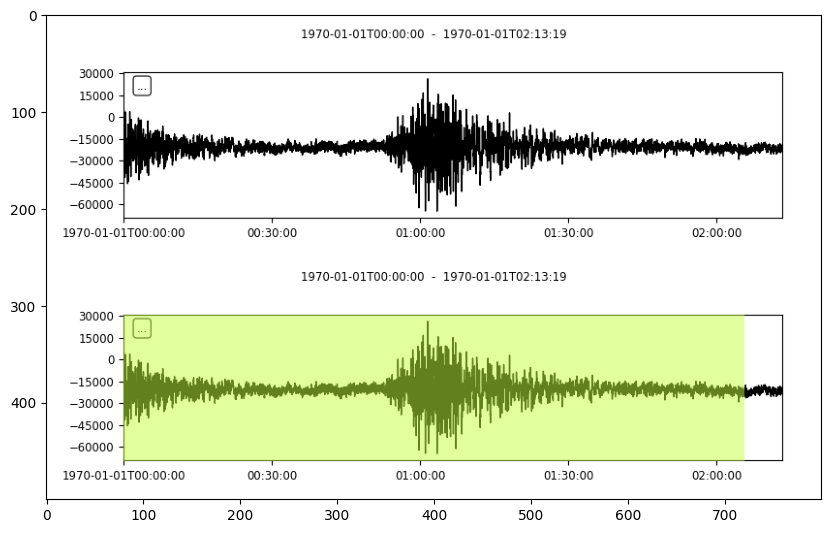

49 : dataset8k_v4/class7/original/202202_15_0__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


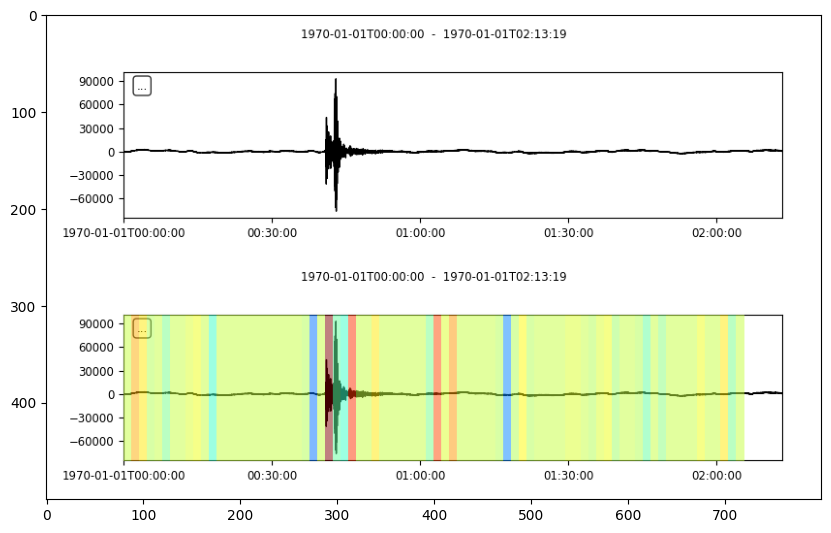

saved 13 files
50 : dataset8k_v4/class7/original/202202_9_1__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 19ms/step


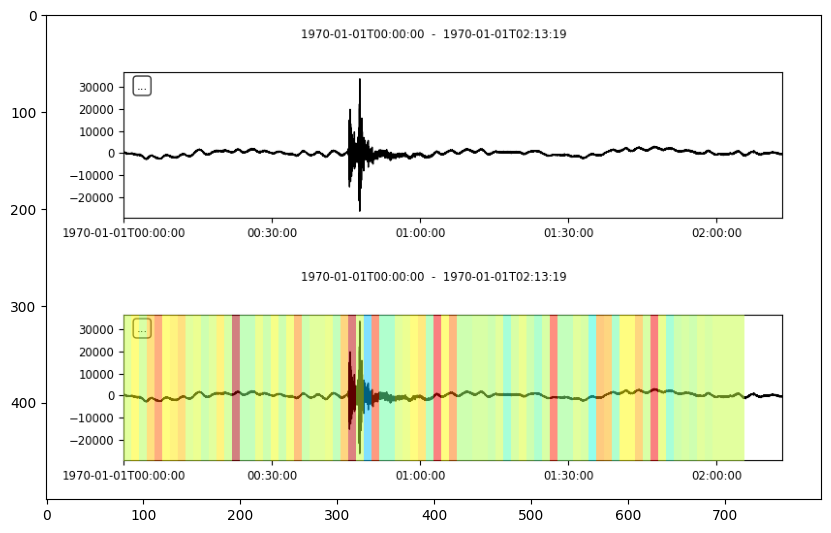

saved 14 files
51 : dataset8k_v4/class7/original/202204_3_3__SIMA.BHZ.KO_original.sac
1/1 [==============================] - 0s 21ms/step


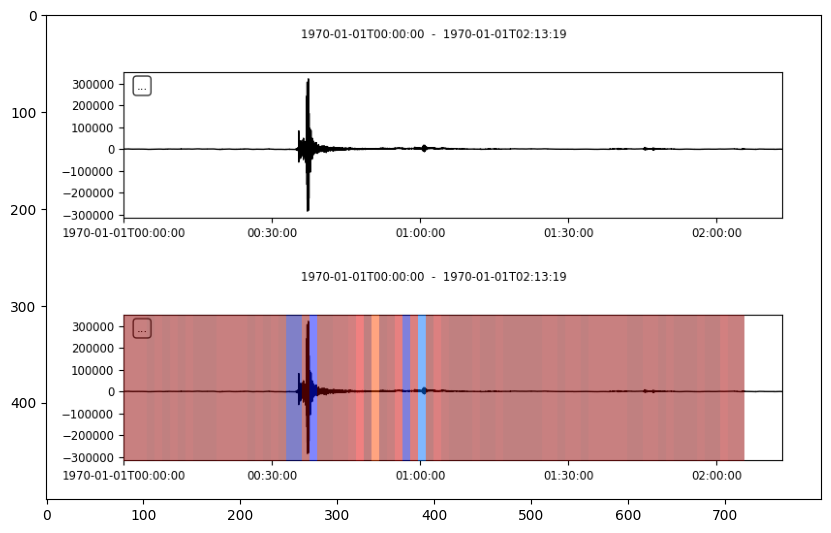

saved 15 files
52 : dataset8k_v4/class7/original/202205_15_47__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 20ms/step


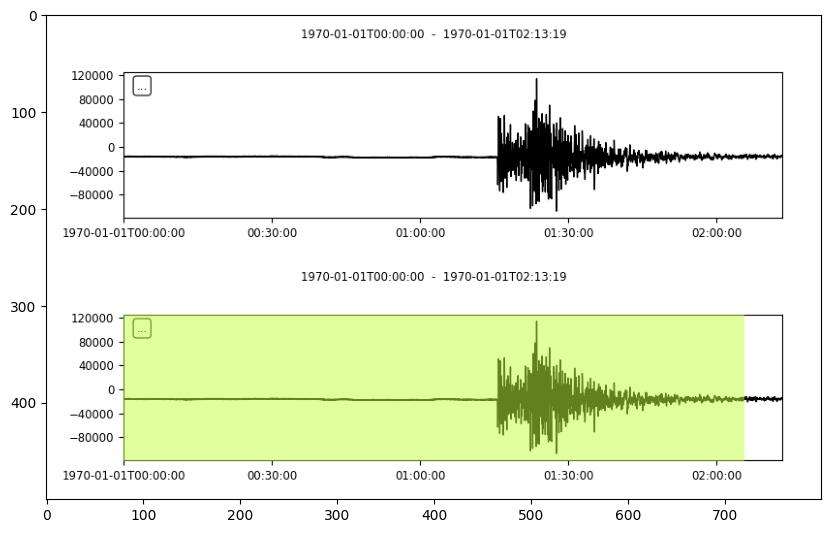

53 : dataset8k_v4/class7/original/202208_22_42__GEDZ.BHZ.KO_original.sac
1/1 [==============================] - 0s 21ms/step


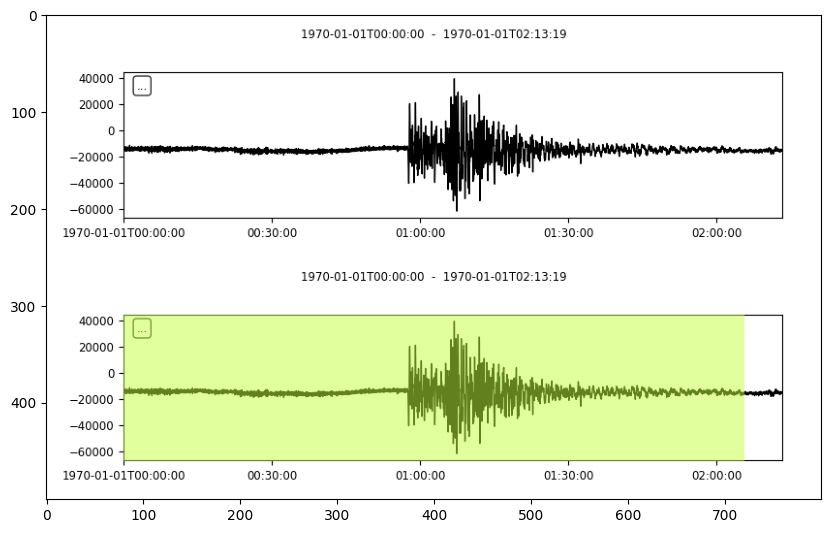

In [8]:

cs = 0 
for i, trace_file in enumerate(original_trace_file_list[31:]):
    path = os.path.join(dataset, original_class_folder, trace_file) 
    print(f"{i} : {path}")
    trace, pred, p_l = colorize(path, divide_number = 80)
    x = input("Press Enter to continue...")
    if x == 'q':
        break
    elif x == 's':
        # copy the file to another folder
        trace.write("./dataset/" + trace_file, format="SAC")
        cs = cs + 1
        print(f"saved {cs} files")


